# HPC Efficiency Analysis — King's Sustainability Month

**Data period:** July – December 2025 (6 months)

This notebook generates plots for the sustainability blog post. All efficiency
values are **filtered to ≤ 100 %** for clarity. Plots are saved to
`../results/plots/2026-02_sustainability/`.

## Contents
1. [Global Efficiency Stats](#1.-Global-Efficiency-Stats)
2. [Faculty Efficiency Stats](#2.-Faculty-Efficiency-Stats)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
import seaborn as sns
import textwrap, os
from scipy import stats as sp_stats
from scipy.stats import gaussian_kde
from IPython.display import display, Markdown

sns.set_theme(style='white')
plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 150,
    'savefig.bbox': 'tight',
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'axes.titlepad': 14,
    'axes.labelpad': 8,
})

PLOT_DIR = '../results/plots/2026-02_sustainability'
os.makedirs(PLOT_DIR, exist_ok=True)

# Colours
C_CPU  = '#2196F3'
C_MEM  = '#4CAF50'
C_TIME = '#9C27B0'
C_OK   = '#4CAF50'
C_FAIL = '#F44336'
C_CAN  = '#9E9E9E'
DATE_RANGE = 'July – December 2025'

# Faculty abbreviations (used in all plots for readability)
FACULTY_ABBREV = {
    'Faculty of Social Science & Public Policy':                'SSPP',
    'Faculty of Natural, Mathematical & Engineering Sciences':  'NMES',
    'Faculty of Dentistry, Oral & Craniofacial Sciences':       'DOCS',
    'Faculty of Life Sciences & Medicine':                      'LSM',
    'Institute of Psychiatry, Psychology & Neuroscience':       'IoPPN',
    'Faculty of Arts & Humanities':                             'AH',
    'Research Management & Innovation':                         'RMI',
    "King's Business School":                                   'KBS',
    'Students & Education':                                     'SE',
    'The Dickson Poon School of Law':                           'DPSL',
    'IT':                                                       'IT',
    'Other':                                                    'Other',
    'unknown':                                                  'N/A',
}

def approx(n, sf=2):
    """Round to sf significant figures and add k/M suffix."""
    if n == 0:
        return '0'
    mag = 10 ** (len(str(abs(int(n)))) - sf)
    rounded = round(n / mag) * mag
    if rounded >= 1_000_000:
        val = rounded / 1_000_000
        return f'~{val:.0f}M' if val == int(val) else f'~{val:.1f}M'
    if rounded >= 1_000:
        val = rounded / 1_000
        return f'~{val:.0f}k' if val == int(val) else f'~{val:.1f}k'
    return f'~{rounded}'

def fmt_count(x, _):
    """Format job counts: k for thousands, M for millions."""
    if abs(x) >= 1_000_000:
        return f'{x / 1_000_000:.1f}M'
    elif abs(x) >= 1_000:
        return f'{x / 1_000:.0f}k'
    else:
        return f'{x:.0f}'

COUNT_FMT = mticker.FuncFormatter(fmt_count)

def savefig(name):
    path = os.path.join(PLOT_DIR, name)
    plt.savefig(path)
    print(f'  Saved {name}')

In [2]:
JOB_CSV = '../results/2025-07-01_2025-12-31_job_level_metrics.csv'
AGG_CSV = '../results/2025-07-01_2025-12-31_hpc_stats_output.csv'

# --- Job-level data (COMPLETED + TIMEOUT + OOM only) ---
df = pd.read_csv(JOB_CSV, comment='#')
df['faculty'] = df['faculty'].str.strip('"')
df = df.replace('NULL', np.nan)

num_cols = [c for c in df.columns
            if c not in ('username', 'faculty', 'submission_type', 'mem_type')]
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')

FACULTY_MERGE = {
    'Faculty of Life Sciences and Medicine':
        'Faculty of Life Sciences & Medicine',
    'IoPPN':
        'Institute of Psychiatry, Psychology & Neuroscience',
    'Dentistry, Oral & Craniofacial Sciences':
        'Faculty of Dentistry, Oral & Craniofacial Sciences',
    'Social Science & Public Policy':
        'Faculty of Social Science & Public Policy',
}
df['faculty'] = df['faculty'].replace(FACULTY_MERGE)

# Use abbreviations for plot labels
df['faculty_short'] = df['faculty'].map(FACULTY_ABBREV).fillna(df['faculty'])
SHORT = dict(zip(df['faculty'], df['faculty_short']))

# --- Aggregate data (all job states, for total counts) ---
df_agg = pd.read_csv(AGG_CSV, comment='#')
df_agg['faculty'] = df_agg['faculty'].str.strip('"')
df_agg['faculty'] = df_agg['faculty'].replace(FACULTY_MERGE)

# Drop the "all" row (global stats appended by --collate_by none)
df_agg = df_agg[df_agg['faculty'] != 'all']

agg_cols = ['job_count', 'job_count_success', 'job_count_failed',
            'count_timeout', 'count_out_of_memory']
df_agg = df_agg.groupby('faculty')[agg_cols].sum().reset_index()
df_agg['cancelled'] = (df_agg['job_count']
                        - df_agg['job_count_success']
                        - df_agg['job_count_failed'])
df_agg['faculty_short'] = df_agg['faculty'].map(FACULTY_ABBREV).fillna(
    df_agg['faculty'])

total_all = df_agg['job_count'].sum()
total_eff = len(df)
total_excluded = total_all - total_eff
print(f'Efficiency jobs: {total_eff:,}  (COMPLETED + TIMEOUT + OOM)')
print(f'Total jobs incl. all states: {total_all:,}')
print(f'Excluded: {total_excluded:,} (CANCELLED + FAILED + NODE_FAIL + PREEMPTED)')
print(f'Date range: {DATE_RANGE}')

Efficiency jobs: 2,916,255  (COMPLETED + TIMEOUT + OOM)
Total jobs incl. all states: 3,717,485
Excluded: 801,230 (CANCELLED + FAILED + NODE_FAIL + PREEMPTED)
Date range: July – December 2025


### Faculty abbreviations

| Abbreviation | Faculty |
|---|---|
| **NMES** | Faculty of Natural, Mathematical & Engineering Sciences |
| **IoPPN** | Institute of Psychiatry, Psychology & Neuroscience |
| **DOCS** | Faculty of Dentistry, Oral & Craniofacial Sciences |
| **LSM** | Faculty of Life Sciences & Medicine |
| **SSPP** | Faculty of Social Science & Public Policy |
| **KBS** | King's Business School |
| **AH** | Faculty of Arts & Humanities |
| **RMI** | Research Management & Innovation |
| **SE** | Students & Education |
| **DPSL** | The Dickson Poon School of Law |
| **IT** | IT |
| **Other** | Listed as "Other" in Active Directory |
| **N/A** | Unknown faculty (LDAP lookup failed) |

*In some plots, RMI, SE, and Other are merged into a single **Other** category.*

---
# 1. Global Efficiency Stats

In [3]:
cpu_valid = df['cpu_eff_req'].dropna()
mem_valid = df['mem_eff'].dropna()
time_valid_all = df['time_eff'].dropna()

cpu_le100 = cpu_valid[cpu_valid <= 100]
mem_le100 = mem_valid[mem_valid <= 100]

# Time efficiency: also exclude sentinel/partition-level time limits (>=365 days)
YEAR_SEC = 365 * 24 * 3600
time_with_limit = df[['time_eff', 'timelimit_sec']].dropna()
n_time_sentinel = (time_with_limit['timelimit_sec'] >= YEAR_SEC).sum()
time_real = time_with_limit[time_with_limit['timelimit_sec'] < YEAR_SEC]
time_le100 = time_real[time_real['time_eff'] <= 100]['time_eff']

# Multi-CPU jobs only
multi_cpu_eff = df.loc[df['req_cpus'] > 1, 'cpu_eff_req'].dropna()
multi_cpu_le100 = multi_cpu_eff[multi_cpu_eff <= 100]
multi_mem_eff = df.loc[df['req_cpus'] > 1, 'mem_eff'].dropna()
multi_mem_le100 = multi_mem_eff[multi_mem_eff <= 100]

below50_cpu = (cpu_le100 < 50).sum()
below50_cpu_pct = below50_cpu / len(cpu_le100) * 100
below50_mem = (mem_le100 < 50).sum()
below50_mem_pct = below50_mem / len(mem_le100) * 100
below50_time = (time_le100 < 50).sum()
below50_time_pct = below50_time / len(time_le100) * 100

cpu_over100 = int((cpu_valid > 100).sum())
mem_over100 = int((mem_valid > 100).sum())
time_over100 = int((time_real['time_eff'] > 100).sum())

display(Markdown(f'''
## Cluster-Wide Summary

| Metric | Value |
|--------|-------|
| **Total jobs submitted** | {approx(total_all)} |
| **Jobs analysed for efficiency** | {approx(total_eff)} |
| **Mean CPU efficiency** | {cpu_le100.mean():.1f} % |
| **Median CPU efficiency** | {cpu_le100.median():.1f} % |
| **Mean memory efficiency** | {mem_le100.mean():.1f} % |
| **Median memory efficiency** | {mem_le100.median():.1f} % |
| **Mean time efficiency** | {time_le100.mean():.1f} % |
| **Median time efficiency** | {time_le100.median():.1f} % |
| **Jobs with CPU eff > 100 %** | {approx(cpu_over100)} ({(cpu_valid > 100).mean()*100:.1f} %, excluded) |
| **Jobs with mem eff > 100 %** | {approx(mem_over100)} ({(mem_valid > 100).mean()*100:.1f} %, excluded) |
| **Jobs with time eff > 100 %** | {approx(time_over100)} ({time_over100/len(time_real)*100:.1f} %, excluded) |
| **Jobs with sentinel time limits** | {approx(n_time_sentinel)} (excluded from time eff) |

### Key findings

Over the last six months, **{approx(total_all)}** jobs were run on CREATE HPC.
Of **{approx(len(cpu_le100))}** jobs we could analyse, the average CPU efficiency
was **{cpu_le100.mean():.0f} %** — **{approx(below50_cpu)}** ({below50_cpu_pct:.0f} %)
used less than half of the CPU time they requested.
The average memory efficiency was **{mem_le100.mean():.0f} %**
(across {approx(len(mem_le100))} jobs) — **{approx(below50_mem)}**
({below50_mem_pct:.0f} %) used less than half of the memory they requested.
The average time efficiency was **{time_le100.mean():.0f} %**
(across {approx(len(time_le100))} jobs) — **{approx(below50_time)}**
({below50_time_pct:.0f} %) used less than half of the wall time they requested.

Among multi-CPU jobs specifically, the average CPU efficiency was only
**{multi_cpu_le100.mean():.0f} %** — **{approx(int((multi_cpu_le100 < 50).sum()))}**
({(multi_cpu_le100 < 50).mean()*100:.0f} %) used less than 50 % of their
requested CPU time.

**Included states:** COMPLETED, TIMEOUT, OUT_OF_MEMORY — jobs that ran long
enough to produce meaningful resource usage data.

**Excluded:** {approx(total_excluded)} jobs in states CANCELLED, FAILED, NODE_FAIL,
and PREEMPTED were excluded from all efficiency analysis because they did not
run to completion and their resource usage is not representative.

Efficiency values above 100 % are excluded from the averages and all plots
below. These arise from Slurm's core-level allocation (CPU) or historically
unenforced memory limits. For time efficiency, jobs with non-user-chosen time
limits (Slurm's INFINITE sentinel or partition-level maximums ≥ 365 days) are
also excluded.
'''))


## Cluster-Wide Summary

| Metric | Value |
|--------|-------|
| **Total jobs submitted** | ~3.7M |
| **Jobs analysed for efficiency** | ~2.9M |
| **Mean CPU efficiency** | 59.9 % |
| **Median CPU efficiency** | 70.6 % |
| **Mean memory efficiency** | 19.3 % |
| **Median memory efficiency** | 8.5 % |
| **Mean time efficiency** | 11.9 % |
| **Median time efficiency** | 2.0 % |
| **Jobs with CPU eff > 100 %** | ~97k (3.4 %, excluded) |
| **Jobs with mem eff > 100 %** | ~270k (9.4 %, excluded) |
| **Jobs with time eff > 100 %** | ~74k (2.5 %, excluded) |
| **Jobs with sentinel time limits** | ~8.9k (excluded from time eff) |

### Key findings

Over the last six months, **~3.7M** jobs were run on CREATE HPC.
Of **~2.8M** jobs we could analyse, the average CPU efficiency
was **60 %** — **~1.1M** (40 %)
used less than half of the CPU time they requested.
The average memory efficiency was **19 %**
(across ~2.6M jobs) — **~2.2M**
(85 %) used less than half of the memory they requested.
The average time efficiency was **12 %**
(across ~2.8M jobs) — **~2.6M**
(92 %) used less than half of the wall time they requested.

Among multi-CPU jobs specifically, the average CPU efficiency was only
**32 %** — **~920k**
(75 %) used less than 50 % of their
requested CPU time.

**Included states:** COMPLETED, TIMEOUT, OUT_OF_MEMORY — jobs that ran long
enough to produce meaningful resource usage data.

**Excluded:** ~800k jobs in states CANCELLED, FAILED, NODE_FAIL,
and PREEMPTED were excluded from all efficiency analysis because they did not
run to completion and their resource usage is not representative.

Efficiency values above 100 % are excluded from the averages and all plots
below. These arise from Slurm's core-level allocation (CPU) or historically
unenforced memory limits. For time efficiency, jobs with non-user-chosen time
limits (Slurm's INFINITE sentinel or partition-level maximums ≥ 365 days) are
also excluded.


In [4]:

# Percentage of jobs using less than 1 GiB of actual memory and less than 1 CPU-hour
mem_used_gib = df['maxrss_bytes'].dropna() / (1024**3)
pct_mem_below_1gib = (mem_used_gib < 1).mean() * 100

cpu_used_hrs = df['total_cpu_sec'].dropna() / 3600
pct_cpu_below_1hr = (cpu_used_hrs < 1).mean() * 100

total_mem = len(mem_used_gib)
total_cpu = len(cpu_used_hrs)

print("=== Jobs using less than defaults ===")
print(f"Jobs using < 1 GiB memory:    {(mem_used_gib < 1).sum():,} / {total_mem:,} ({pct_mem_below_1gib:.1f} %)")
print(f"Jobs using < 1 CPU-hour:      {(cpu_used_hrs < 1).sum():,} / {total_cpu:,} ({pct_cpu_below_1hr:.1f} %)")


=== Jobs using less than defaults ===
Jobs using < 1 GiB memory:    1,970,562 / 2,916,255 (67.6 %)
Jobs using < 1 CPU-hour:      2,307,546 / 2,916,255 (79.1 %)


  Saved job_state_distribution.png


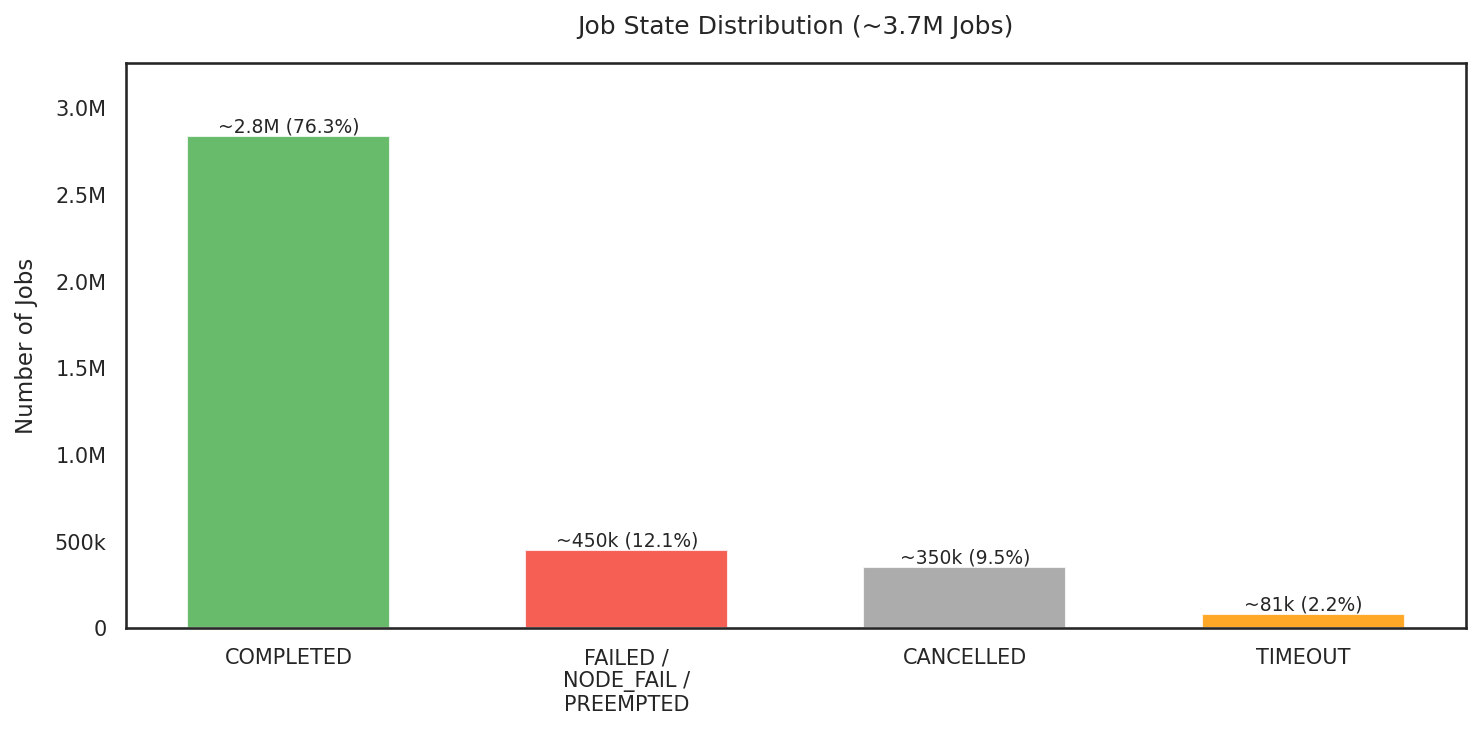


**Included in efficiency analysis:** COMPLETED + TIMEOUT + OOM
= **~2.9M** jobs.

**Excluded:** CANCELLED + FAILED + NODE_FAIL + PREEMPTED
= **~800k** jobs — these either did not run long enough or
terminated abnormally, so their resource usage is not representative.


*Note: No OUT_OF_MEMORY jobs were recorded in this period because memory limits were not enforced via cgroups on the cluster at the time.*


In [5]:
# State breakdown from aggregate data
agg_completed = df_agg['job_count_success'].sum()
agg_timeout = df_agg['count_timeout'].sum()
agg_oom = df_agg['count_out_of_memory'].sum()
agg_failed_total = df_agg['job_count_failed'].sum()
agg_other_failed = agg_failed_total - agg_timeout - agg_oom
agg_cancelled = df_agg['cancelled'].sum()

# Drop OOM bar if count is 0 (no memory limits enforced in this period)
state_labels = ['COMPLETED', 'FAILED /\nNODE_FAIL /\nPREEMPTED', 'CANCELLED', 'TIMEOUT']
state_counts = [agg_completed, agg_other_failed, agg_cancelled, agg_timeout]
state_colors = [C_OK, C_FAIL, C_CAN, '#FF9800']

if agg_oom > 0:
    state_labels.append('OOM')
    state_counts.append(agg_oom)
    state_colors.append('#9C27B0')

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(state_labels, state_counts, color=state_colors, edgecolor='white',
              width=0.6, alpha=0.85)

for bar, count in zip(bars, state_counts):
    pct = count / total_all * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f'{approx(count)} ({pct:.1f}%)', ha='center', va='bottom', fontsize=9)

ax.set_ylabel('Number of Jobs')
y_max = max(state_counts)
ax.set_ylim(0, y_max * 1.15)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else
                 f'{x/1e3:.0f}k' if x >= 1e3 else f'{x:.0f}'))
ax.set_title(f'Job State Distribution ({approx(total_all)} Jobs)')
plt.tight_layout()
savefig('job_state_distribution.png')
plt.show()

oom_note = ''
if agg_oom == 0:
    oom_note = ('\n\n*Note: No OUT_OF_MEMORY jobs were recorded in this period '
                'because memory limits were not enforced via cgroups on the cluster '
                'at the time.*')

display(Markdown(f'''
**Included in efficiency analysis:** COMPLETED + TIMEOUT + OOM
= **{approx(total_eff)}** jobs.

**Excluded:** CANCELLED + FAILED + NODE_FAIL + PREEMPTED
= **{approx(total_excluded)}** jobs — these either did not run long enough or
terminated abnormally, so their resource usage is not representative.
{oom_note}
'''))

<>:31: SyntaxWarning: invalid escape sequence '\>'
<>:31: SyntaxWarning: invalid escape sequence '\>'
/tmp/ipykernel_1766848/3789128029.py:31: SyntaxWarning: invalid escape sequence '\>'


  Saved cpu_efficiency_density.png


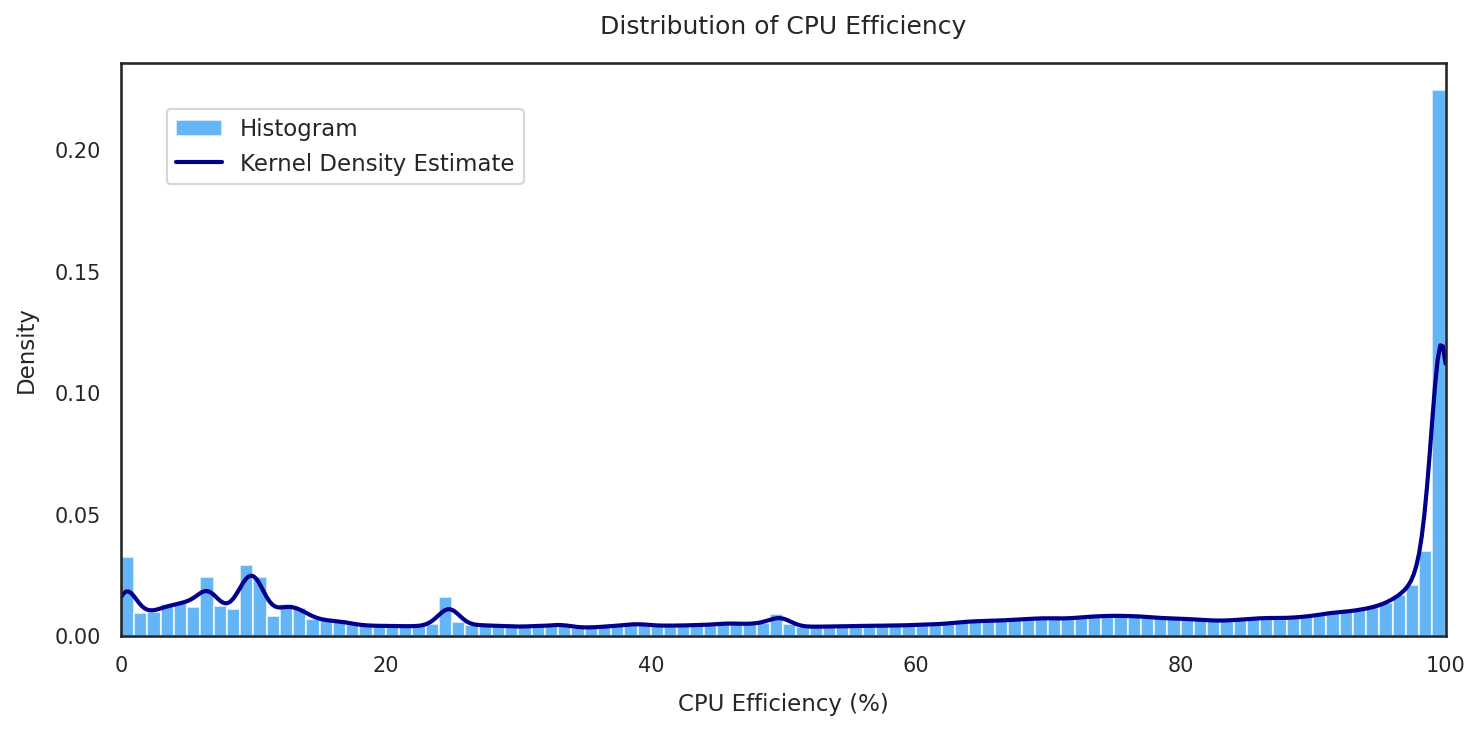


*Based on **~2.8M** jobs. From ~2.9M efficiency jobs,
~11k with null CPU efficiency and ~97k with CPU efficiency
\> 100% were excluded.*


In [6]:
cpu_data = df['cpu_eff_req'].dropna()
cpu_plot = cpu_data[cpu_data <= 100]
cpu_null = total_eff - len(cpu_data)
cpu_over = len(cpu_data) - len(cpu_plot)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(cpu_plot, bins=100, color=C_CPU, alpha=0.7, edgecolor='white',
        density=True, label='Histogram')

# KDE overlay (subsample for speed)
sample = cpu_plot.sample(min(500_000, len(cpu_plot)), random_state=42)
kde = gaussian_kde(sample, bw_method=0.02)
x_grid = np.linspace(0, 100, 500)
ax.plot(x_grid, kde(x_grid), color='darkblue', lw=2, label='Kernel Density Estimate')

ax.set_xlabel('CPU Efficiency (%)')
ax.set_ylabel('Density')
ax.set_title('Distribution of CPU Efficiency')
ax.set_xlim(0, 100)
ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=5))
ax.legend(loc='upper left', borderaxespad=2)
plt.tight_layout()
savefig('cpu_efficiency_density.png')
plt.show()

display(Markdown(f'''
*Based on **{approx(len(cpu_plot))}** jobs. From {approx(total_eff)} efficiency jobs,
{approx(cpu_null)} with null CPU efficiency and {approx(cpu_over)} with CPU efficiency
\> 100% were excluded.*
'''))

  Saved cpu_efficiency_density_split.png


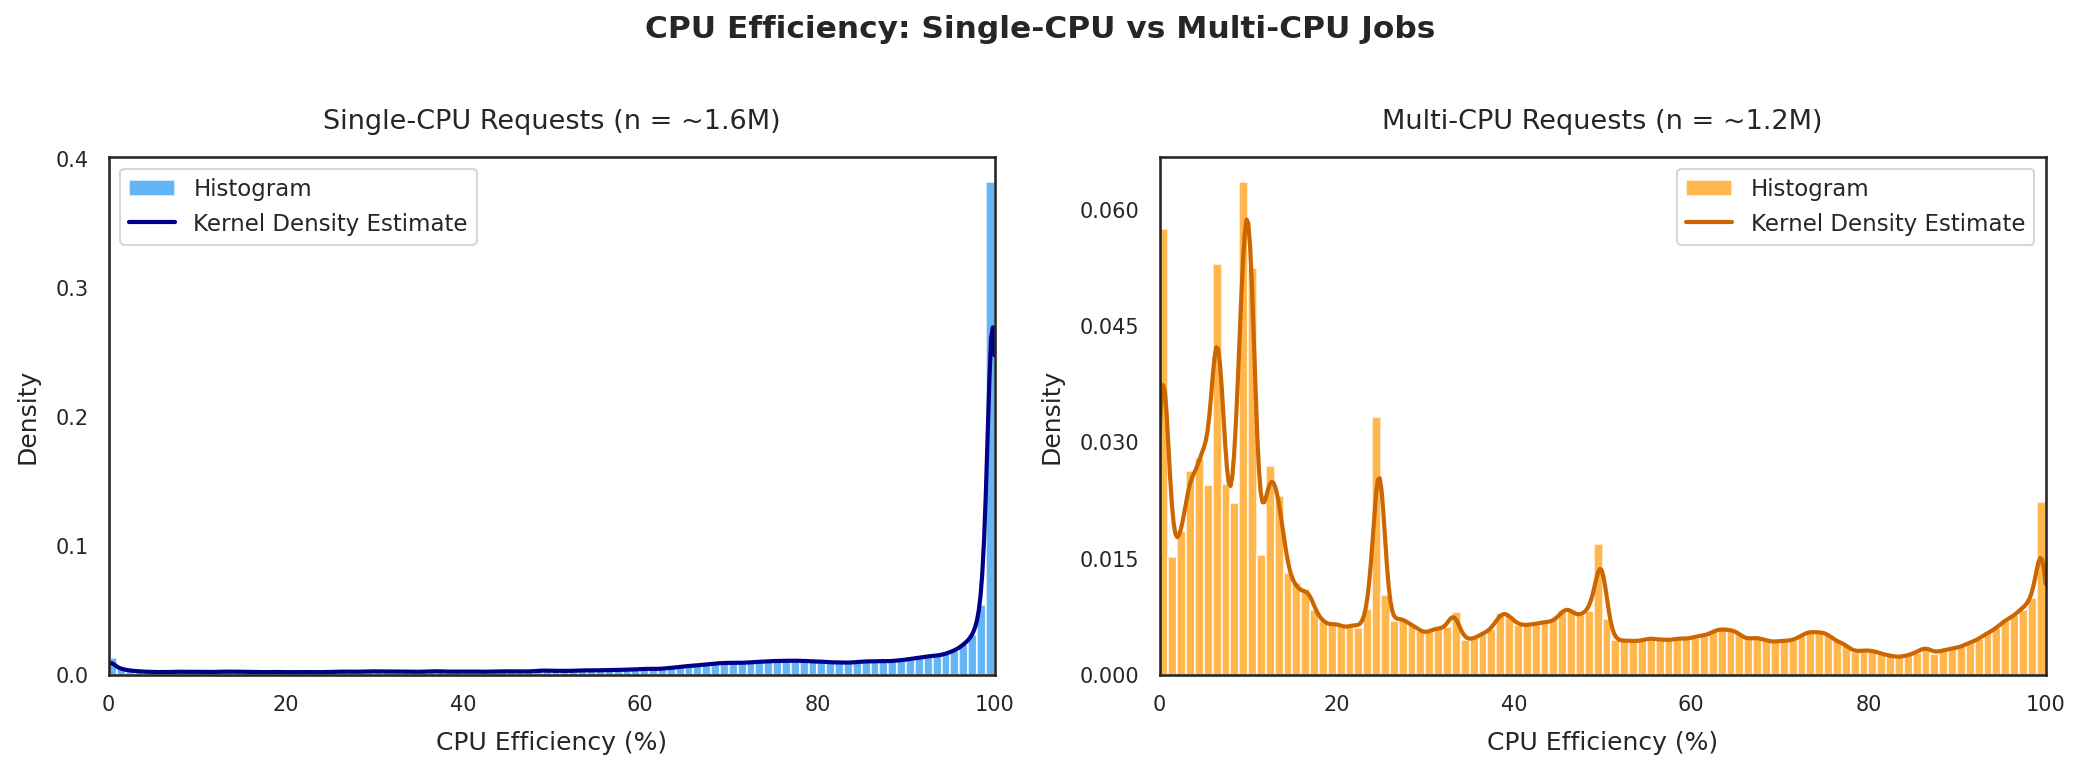


*Left: ~1.6M single-CPU jobs (efficiency ≤ 100 %,
~97k excluded).
Right: ~1.2M multi-CPU jobs (efficiency ≤ 100 %,
~100 excluded).*

*Note: The y-axis scales differ between the two panels — single-CPU jobs
have a much sharper peak near 100 %, so the density scale is higher.*


In [7]:

# Split by single-CPU vs multi-CPU jobs
single_cpu = df[df['req_cpus'] == 1]
multi_cpu_all = df[df['req_cpus'] > 1]

single_cpu_eff = single_cpu['cpu_eff_req'].dropna()
single_cpu_plot = single_cpu_eff[single_cpu_eff <= 100]

multi_cpu_eff = multi_cpu_all['cpu_eff_req'].dropna()
multi_cpu_plot = multi_cpu_eff[multi_cpu_eff <= 100]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, data, color, dark, title, leg_loc in [
    (axes[0], single_cpu_plot, C_CPU, 'darkblue',
     'Single-CPU Requests', 'upper left'),
    (axes[1], multi_cpu_plot, '#FF9800', '#CC6600',
     'Multi-CPU Requests', 'upper right'),
]:
    ax.hist(data, bins=100, color=color, alpha=0.7, edgecolor='white',
            density=True, label='Histogram')
    sample = data.sample(min(500_000, len(data)), random_state=42)
    kde = gaussian_kde(sample, bw_method=0.02)
    x_grid = np.linspace(0, 100, 500)
    ax.plot(x_grid, kde(x_grid), color=dark, lw=2, label='Kernel Density Estimate')
    ax.set_xlabel('CPU Efficiency (%)', fontsize=12)
    ax.set_ylabel('Density', fontsize=12)
    ax.set_title(f'{title} (n = {approx(len(data))})', fontsize=13)
    ax.set_xlim(0, 100)
    ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=5))
    ax.legend(loc=leg_loc)

fig.suptitle('CPU Efficiency: Single-CPU vs Multi-CPU Jobs',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
savefig('cpu_efficiency_density_split.png')
plt.show()

display(Markdown(f'''
*Left: {approx(len(single_cpu_plot))} single-CPU jobs (efficiency ≤ 100 %,
{approx(len(single_cpu_eff) - len(single_cpu_plot))} excluded).
Right: {approx(len(multi_cpu_plot))} multi-CPU jobs (efficiency ≤ 100 %,
{approx(len(multi_cpu_eff) - len(multi_cpu_plot))} excluded).*

*Note: The y-axis scales differ between the two panels — single-CPU jobs
have a much sharper peak near 100 %, so the density scale is higher.*
'''))


In [8]:

# Mean and median CPU efficiency for single-CPU vs multi-CPU jobs
print("=== CPU efficiency by job type (eff <= 100%) ===")
print(f"Single-CPU jobs: n = {len(single_cpu_plot):,}")
print(f"  Mean:   {single_cpu_plot.mean():.1f} %")
print(f"  Median: {single_cpu_plot.median():.1f} %")
print()
print(f"Multi-CPU jobs:  n = {len(multi_cpu_plot):,}")
print(f"  Mean:   {multi_cpu_plot.mean():.1f} %")
print(f"  Median: {multi_cpu_plot.median():.1f} %")


=== CPU efficiency by job type (eff <= 100%) ===
Single-CPU jobs: n = 1,581,374
  Mean:   81.8 %
  Median: 95.5 %

Multi-CPU jobs:  n = 1,226,090
  Mean:   31.7 %
  Median: 18.6 %


<>:30: SyntaxWarning: invalid escape sequence '\>'
<>:30: SyntaxWarning: invalid escape sequence '\>'
/tmp/ipykernel_1766848/2143087949.py:30: SyntaxWarning: invalid escape sequence '\>'
  


  Saved mem_efficiency_density.png


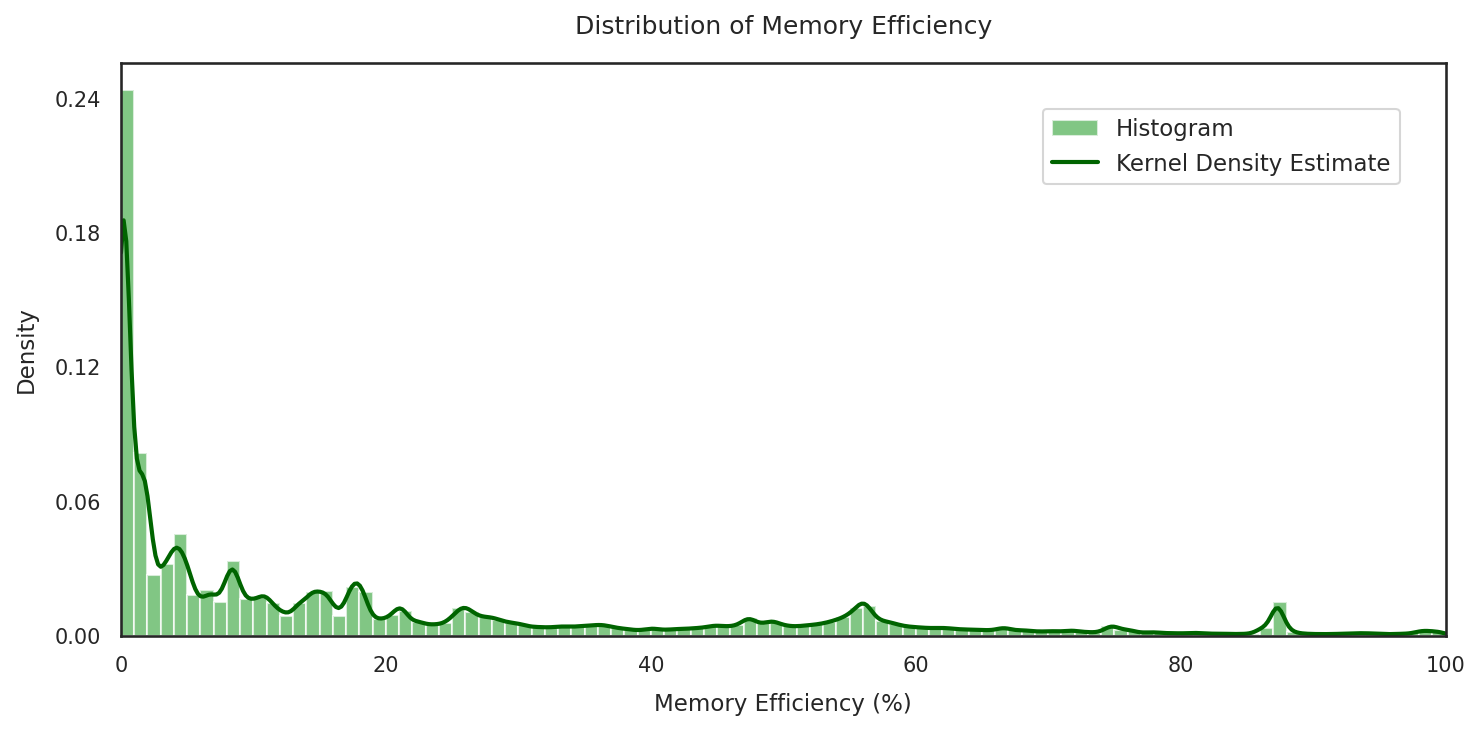


*Based on **~2.6M** jobs. From ~2.9M efficiency jobs,
~270 with null memory efficiency and ~270k with memory
efficiency \> 100% were excluded.*


  Saved mem_efficiency_density_split.png


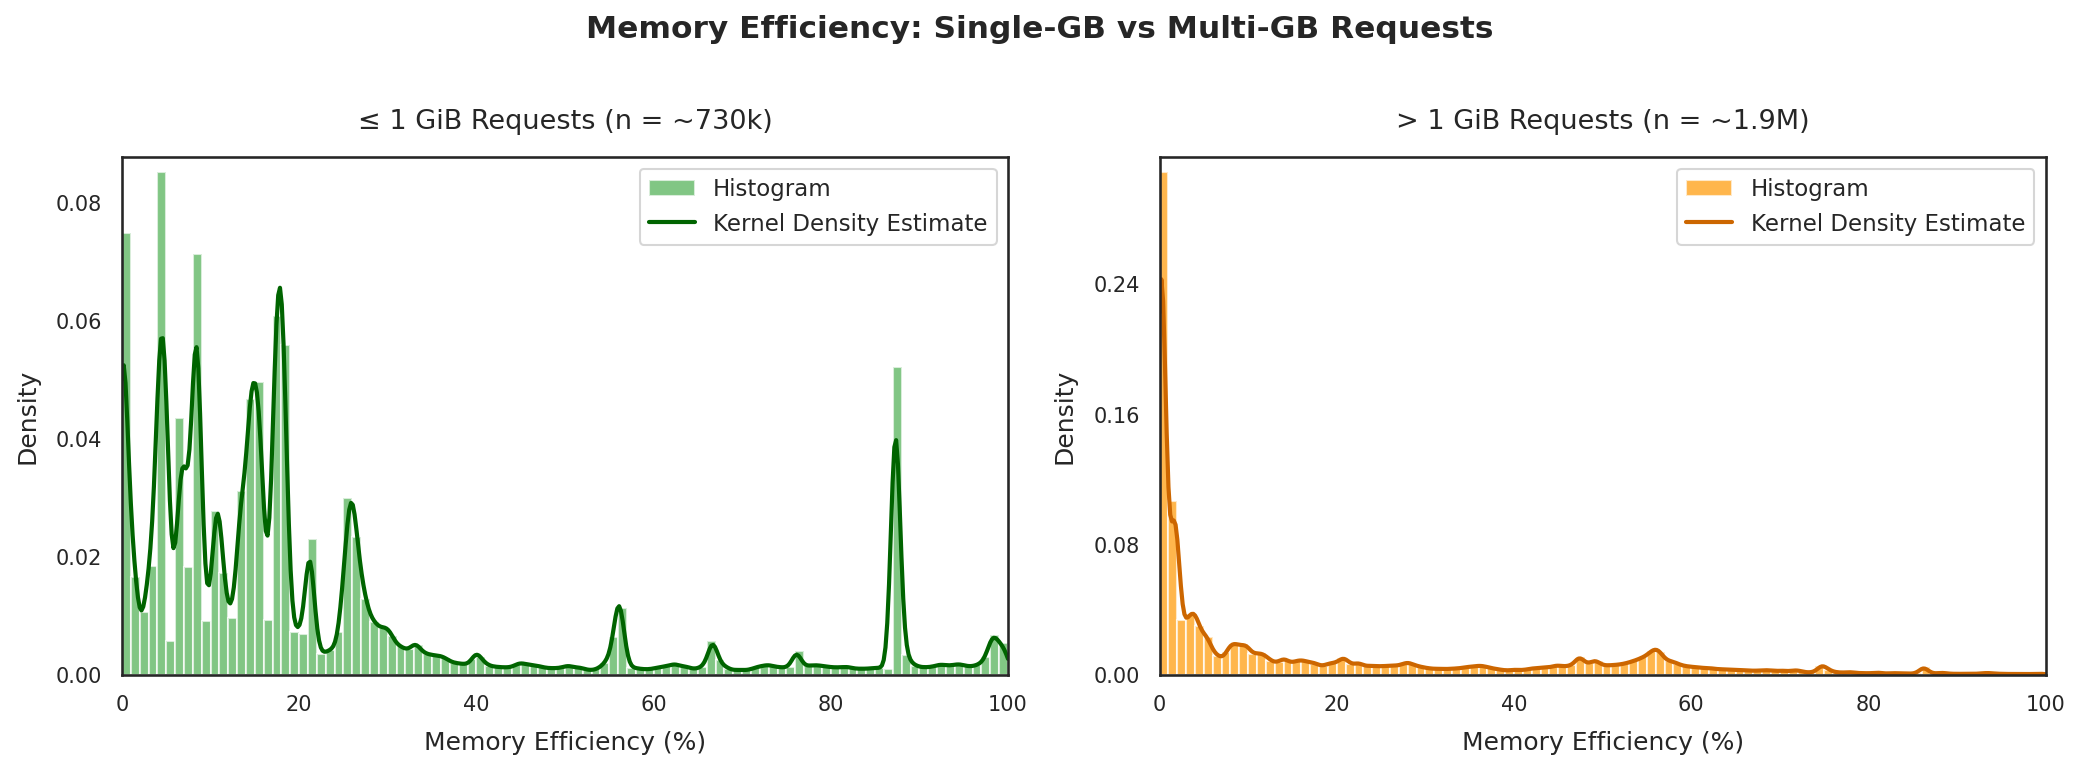


*Left: ~730k jobs requesting ≤ 1 GiB (efficiency ≤ 100 %,
~180k excluded).
Right: ~1.9M jobs requesting > 1 GiB (efficiency ≤ 100 %,
~98k excluded).*

*Note: The y-axis scales differ between the two panels — jobs requesting
≤ 1 GiB show more variation across the efficiency range, while larger
requests are dominated by very low efficiency values.*


In [9]:
mem_data = df['mem_eff'].dropna()
mem_plot = mem_data[mem_data <= 100]
mem_null = total_eff - len(mem_data)
mem_over = len(mem_data) - len(mem_plot)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(mem_plot, bins=100, color=C_MEM, alpha=0.7, edgecolor='white',
        density=True, label='Histogram')

sample = mem_plot.sample(min(500_000, len(mem_plot)), random_state=42)
kde = gaussian_kde(sample, bw_method=0.02)
x_grid = np.linspace(0, 100, 500)
ax.plot(x_grid, kde(x_grid), color='darkgreen', lw=2, label='Kernel Density Estimate')

ax.set_xlabel('Memory Efficiency (%)')
ax.set_ylabel('Density')
ax.set_title('Distribution of Memory Efficiency')
ax.set_xlim(0, 100)
ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=5))
ax.legend(loc='upper right', borderaxespad=2)
plt.tight_layout()
savefig('mem_efficiency_density.png')
plt.show()

display(Markdown(f'''
*Based on **{approx(len(mem_plot))}** jobs. From {approx(total_eff)} efficiency jobs,
{approx(mem_null)} with null memory efficiency and {approx(mem_over)} with memory
efficiency \> 100% were excluded.*
'''))

# --- Split by single-GB vs multi-GB memory requests ---
mem_req_gib = df['reqmem_bytes'].dropna() / (1024**3)
df_with_mem = df[df['reqmem_bytes'].notna()].copy()
df_with_mem['reqmem_gib'] = df_with_mem['reqmem_bytes'] / (1024**3)

single_gb = df_with_mem[df_with_mem['reqmem_gib'] <= 1]
multi_gb = df_with_mem[df_with_mem['reqmem_gib'] > 1]

single_gb_eff = single_gb['mem_eff'].dropna()
single_gb_plot = single_gb_eff[single_gb_eff <= 100]

multi_gb_eff = multi_gb['mem_eff'].dropna()
multi_gb_plot = multi_gb_eff[multi_gb_eff <= 100]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, data, color, dark, title in [
    (axes[0], single_gb_plot, C_MEM, 'darkgreen',
     '\u2264 1 GiB Requests'),
    (axes[1], multi_gb_plot, '#FF9800', '#CC6600',
     '> 1 GiB Requests'),
]:
    n, bin_edges, _ = ax.hist(data, bins=100, color=color, alpha=0.7,
                              edgecolor='white', density=True, label='Histogram')
    if len(data) > 10:
        sample = data.sample(min(500_000, len(data)), random_state=42)
        kde = gaussian_kde(sample, bw_method=0.02)
        x_grid = np.linspace(0, 100, 500)
        kde_vals = kde(x_grid)
        ax.plot(x_grid, kde_vals, color=dark, lw=2, label='Kernel Density Estimate')
        y_top = max(n.max(), kde_vals.max()) * 1.03
    else:
        y_top = n.max() * 1.03
    ax.set_xlabel('Memory Efficiency (%)', fontsize=12)
    ax.set_ylabel('Density', fontsize=12)
    ax.set_title(f'{title} (n = {approx(len(data))})', fontsize=13)
    ax.set_xlim(0, 100)
    ax.set_ylim(0, y_top)
    ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=5))
    ax.legend(loc='upper right')

plt.suptitle('Memory Efficiency: Single-GB vs Multi-GB Requests',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
savefig('mem_efficiency_density_split.png')
plt.show()

display(Markdown(f'''
*Left: {approx(len(single_gb_plot))} jobs requesting ≤ 1 GiB (efficiency ≤ 100 %,
{approx(len(single_gb_eff) - len(single_gb_plot))} excluded).
Right: {approx(len(multi_gb_plot))} jobs requesting > 1 GiB (efficiency ≤ 100 %,
{approx(len(multi_gb_eff) - len(multi_gb_plot))} excluded).*

*Note: The y-axis scales differ between the two panels — jobs requesting
≤ 1 GiB show more variation across the efficiency range, while larger
requests are dominated by very low efficiency values.*
'''))


In [10]:

# Mean and median memory efficiency for single-GB vs multi-GB requests
print("=== Memory efficiency by request size (eff <= 100%) ===")
print(f"≤ 1 GiB requests: n = {len(single_gb_plot):,}")
print(f"  Mean:   {single_gb_plot.mean():.1f} %")
print(f"  Median: {single_gb_plot.median():.1f} %")
print()
print(f"> 1 GiB requests:  n = {len(multi_gb_plot):,}")
print(f"  Mean:   {multi_gb_plot.mean():.1f} %")
print(f"  Median: {multi_gb_plot.median():.1f} %")


=== Memory efficiency by request size (eff <= 100%) ===
≤ 1 GiB requests: n = 734,991
  Mean:   23.6 %
  Median: 15.3 %

> 1 GiB requests:  n = 1,906,835
  Mean:   17.6 %
  Median: 4.4 %


<>:36: SyntaxWarning: invalid escape sequence '\>'
<>:36: SyntaxWarning: invalid escape sequence '\>'
/tmp/ipykernel_1766848/1219334589.py:36: SyntaxWarning: invalid escape sequence '\>'
  


  Saved time_efficiency_density.png


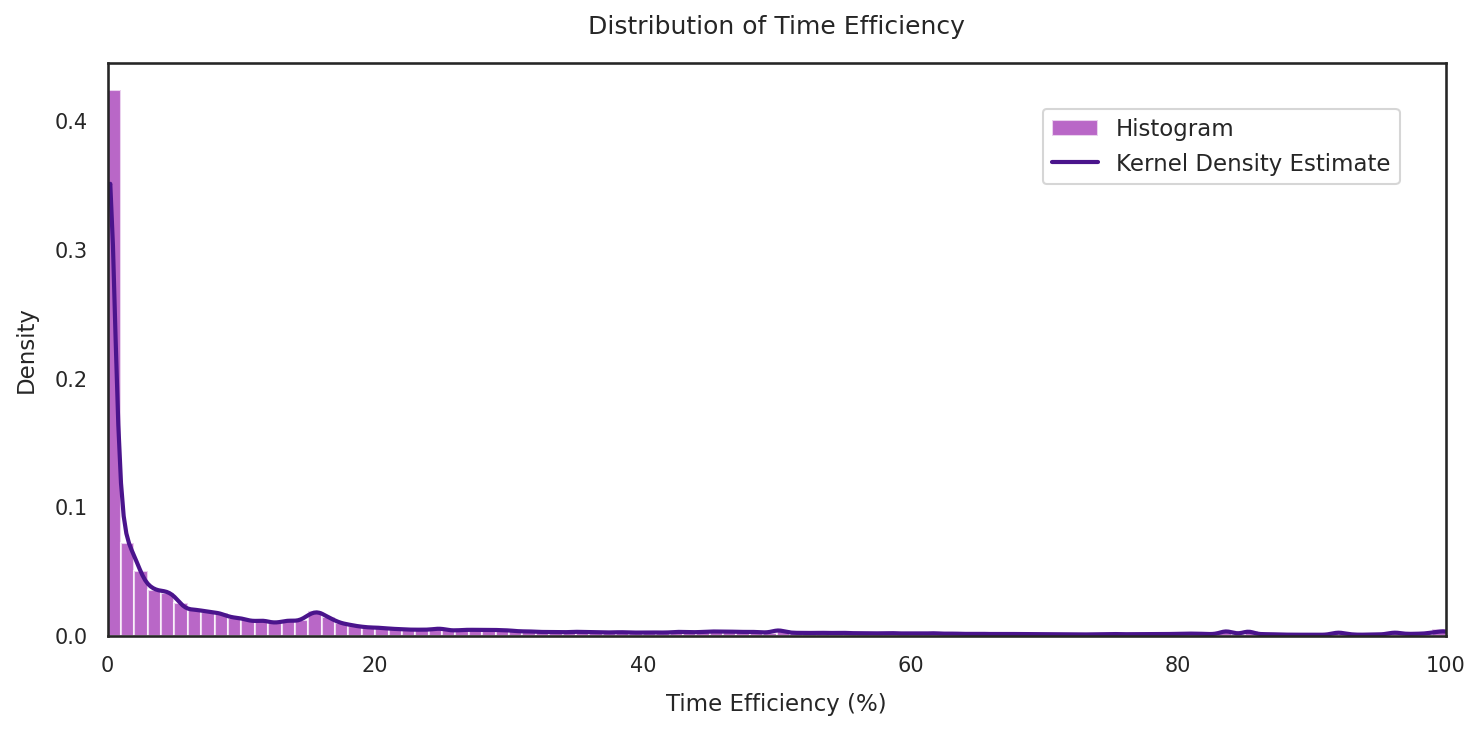


*Based on **~2.8M** jobs. From ~2.9M efficiency jobs,
~270 with null time efficiency, ~8.9k with
non-user-chosen time limits (≥ 365 days), and ~74k with time efficiency
\> 100% were excluded.*


  Saved time_efficiency_density_split.png


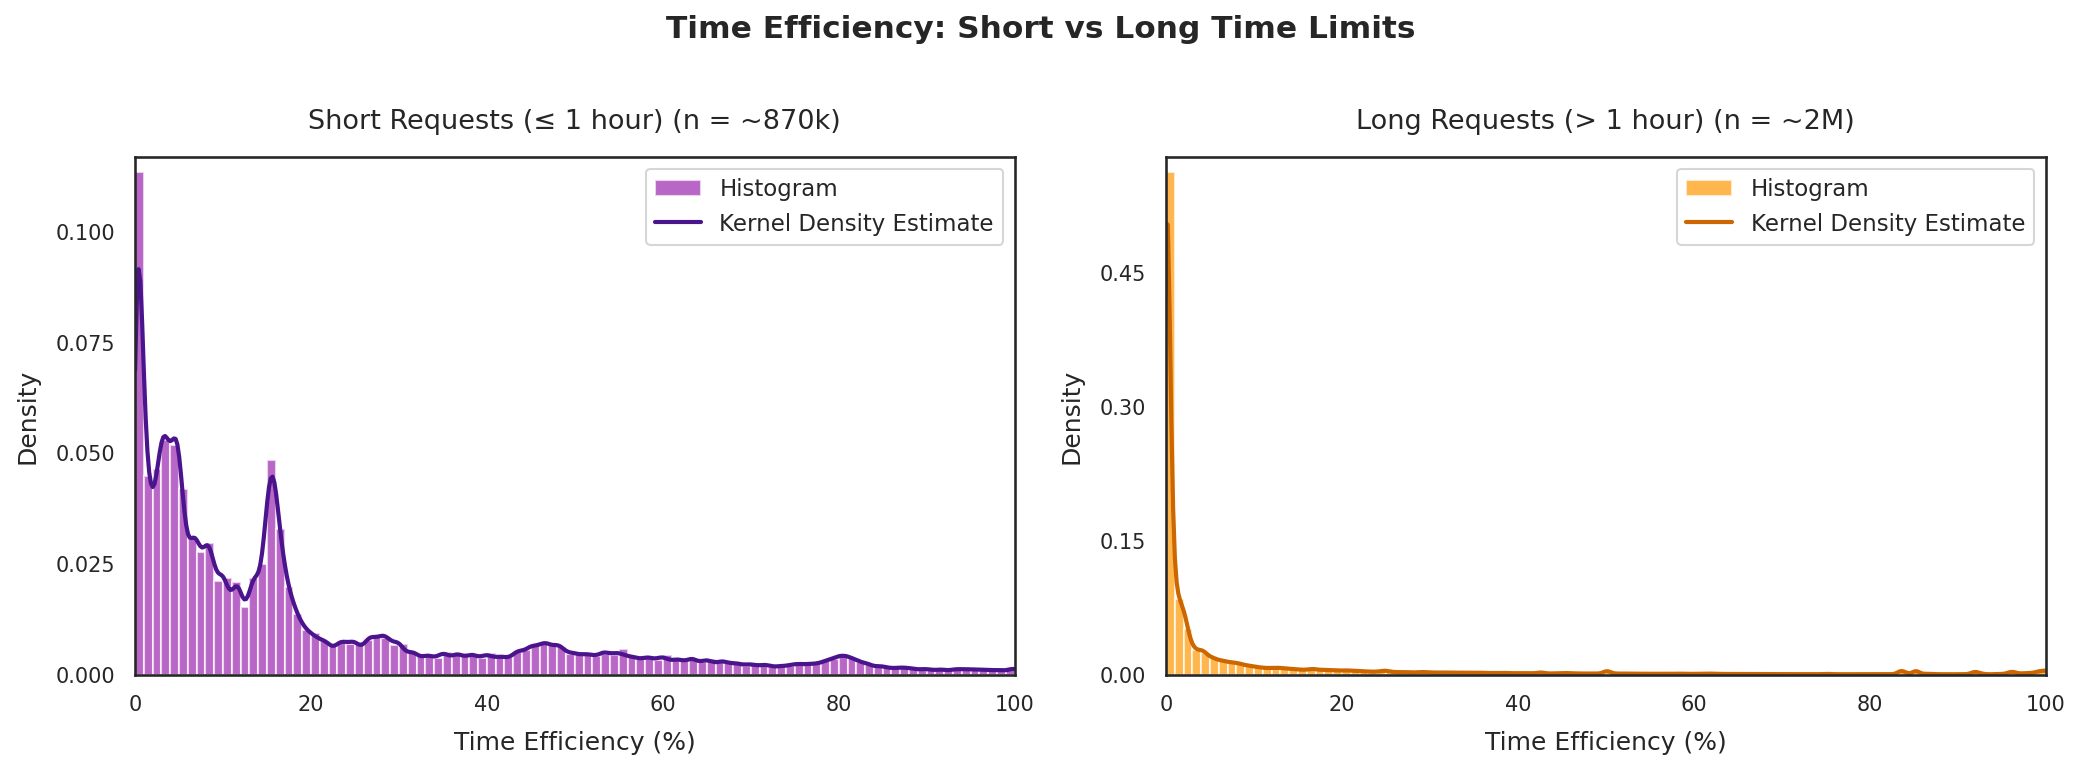


*Left: ~870k jobs requesting ≤ 1 hour (efficiency ≤ 100 %,
~34k excluded).
Right: ~2M jobs requesting > 1 hour (efficiency ≤ 100 %,
~40k excluded).*

*Note: The y-axis scales differ between the two panels.*


In [11]:
# --- Time efficiency density plot ---
# Exclude sentinel/partition-level time limits (>=365 days) and >100%
time_data_all = df['time_eff'].dropna()
time_with_lim = df[['time_eff', 'timelimit_sec']].dropna()
n_time_sentinel = (time_with_lim['timelimit_sec'] >= 365 * 24 * 3600).sum()
time_real = time_with_lim[time_with_lim['timelimit_sec'] < 365 * 24 * 3600]
time_plot = time_real[time_real['time_eff'] <= 100]['time_eff']
time_null = total_eff - len(time_data_all)
time_over = len(time_real) - len(time_plot)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(time_plot, bins=100, color=C_TIME, alpha=0.7, edgecolor='white',
        density=True, label='Histogram')

sample = time_plot.sample(min(500_000, len(time_plot)), random_state=42)
kde = gaussian_kde(sample, bw_method=0.02)
x_grid = np.linspace(0, 100, 500)
ax.plot(x_grid, kde(x_grid), color='#4A148C', lw=2, label='Kernel Density Estimate')

ax.set_xlabel('Time Efficiency (%)')
ax.set_ylabel('Density')
ax.set_title('Distribution of Time Efficiency')
ax.set_xlim(0, 100)
ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=5))
ax.legend(loc='upper right', borderaxespad=2)
plt.tight_layout()
savefig('time_efficiency_density.png')
plt.show()

display(Markdown(f'''
*Based on **{approx(len(time_plot))}** jobs. From {approx(total_eff)} efficiency jobs,
{approx(time_null)} with null time efficiency, {approx(n_time_sentinel)} with
non-user-chosen time limits (≥ 365 days), and {approx(time_over)} with time efficiency
\> 100% were excluded.*
'''))

# --- Split by short (<=1h) vs long (>1h) time limits ---
time_real_hrs = time_real.copy()
time_real_hrs['limit_hrs'] = time_real_hrs['timelimit_sec'] / 3600

short_time = time_real_hrs[time_real_hrs['limit_hrs'] <= 1]
long_time = time_real_hrs[time_real_hrs['limit_hrs'] > 1]

short_time_plot = short_time[short_time['time_eff'] <= 100]['time_eff']
long_time_plot = long_time[long_time['time_eff'] <= 100]['time_eff']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, data, color, dark, title in [
    (axes[0], short_time_plot, C_TIME, '#4A148C',
     'Short Requests (\u2264 1 hour)'),
    (axes[1], long_time_plot, '#FF9800', '#CC6600',
     'Long Requests (> 1 hour)'),
]:
    n, bin_edges, _ = ax.hist(data, bins=100, color=color, alpha=0.7,
                              edgecolor='white', density=True, label='Histogram')
    if len(data) > 10:
        sample = data.sample(min(500_000, len(data)), random_state=42)
        kde = gaussian_kde(sample, bw_method=0.02)
        x_grid = np.linspace(0, 100, 500)
        kde_vals = kde(x_grid)
        ax.plot(x_grid, kde_vals, color=dark, lw=2, label='Kernel Density Estimate')
        y_top = max(n.max(), kde_vals.max()) * 1.03
    else:
        y_top = n.max() * 1.03
    ax.set_xlabel('Time Efficiency (%)', fontsize=12)
    ax.set_ylabel('Density', fontsize=12)
    ax.set_title(f'{title} (n = {approx(len(data))})', fontsize=13)
    ax.set_xlim(0, 100)
    ax.set_ylim(0, y_top)
    ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=5))
    ax.legend(loc='upper right')

plt.suptitle('Time Efficiency: Short vs Long Time Limits',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
savefig('time_efficiency_density_split.png')
plt.show()

display(Markdown(f'''
*Left: {approx(len(short_time_plot))} jobs requesting ≤ 1 hour (efficiency ≤ 100 %,
{approx(len(short_time[short_time["time_eff"].notna()]) - len(short_time_plot))} excluded).
Right: {approx(len(long_time_plot))} jobs requesting > 1 hour (efficiency ≤ 100 %,
{approx(len(long_time[long_time["time_eff"].notna()]) - len(long_time_plot))} excluded).*

*Note: The y-axis scales differ between the two panels.*
'''))

In [12]:

# Mean and median time efficiency for short vs long time limits
print("=== Time efficiency by request size (eff <= 100%) ===")
print(f"Short (\u2264 1 hour): n = {len(short_time_plot):,}")
print(f"  Mean:   {short_time_plot.mean():.1f} %")
print(f"  Median: {short_time_plot.median():.1f} %")
print()
print(f"Long (> 1 hour):  n = {len(long_time_plot):,}")
print(f"  Mean:   {long_time_plot.mean():.1f} %")
print(f"  Median: {long_time_plot.median():.1f} %")

=== Time efficiency by request size (eff <= 100%) ===
Short (≤ 1 hour): n = 870,084
  Mean:   20.3 %
  Median: 11.7 %

Long (> 1 hour):  n = 1,963,445
  Mean:   8.1 %
  Median: 0.5 %


/tmp/ipykernel_1766848/4100292313.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


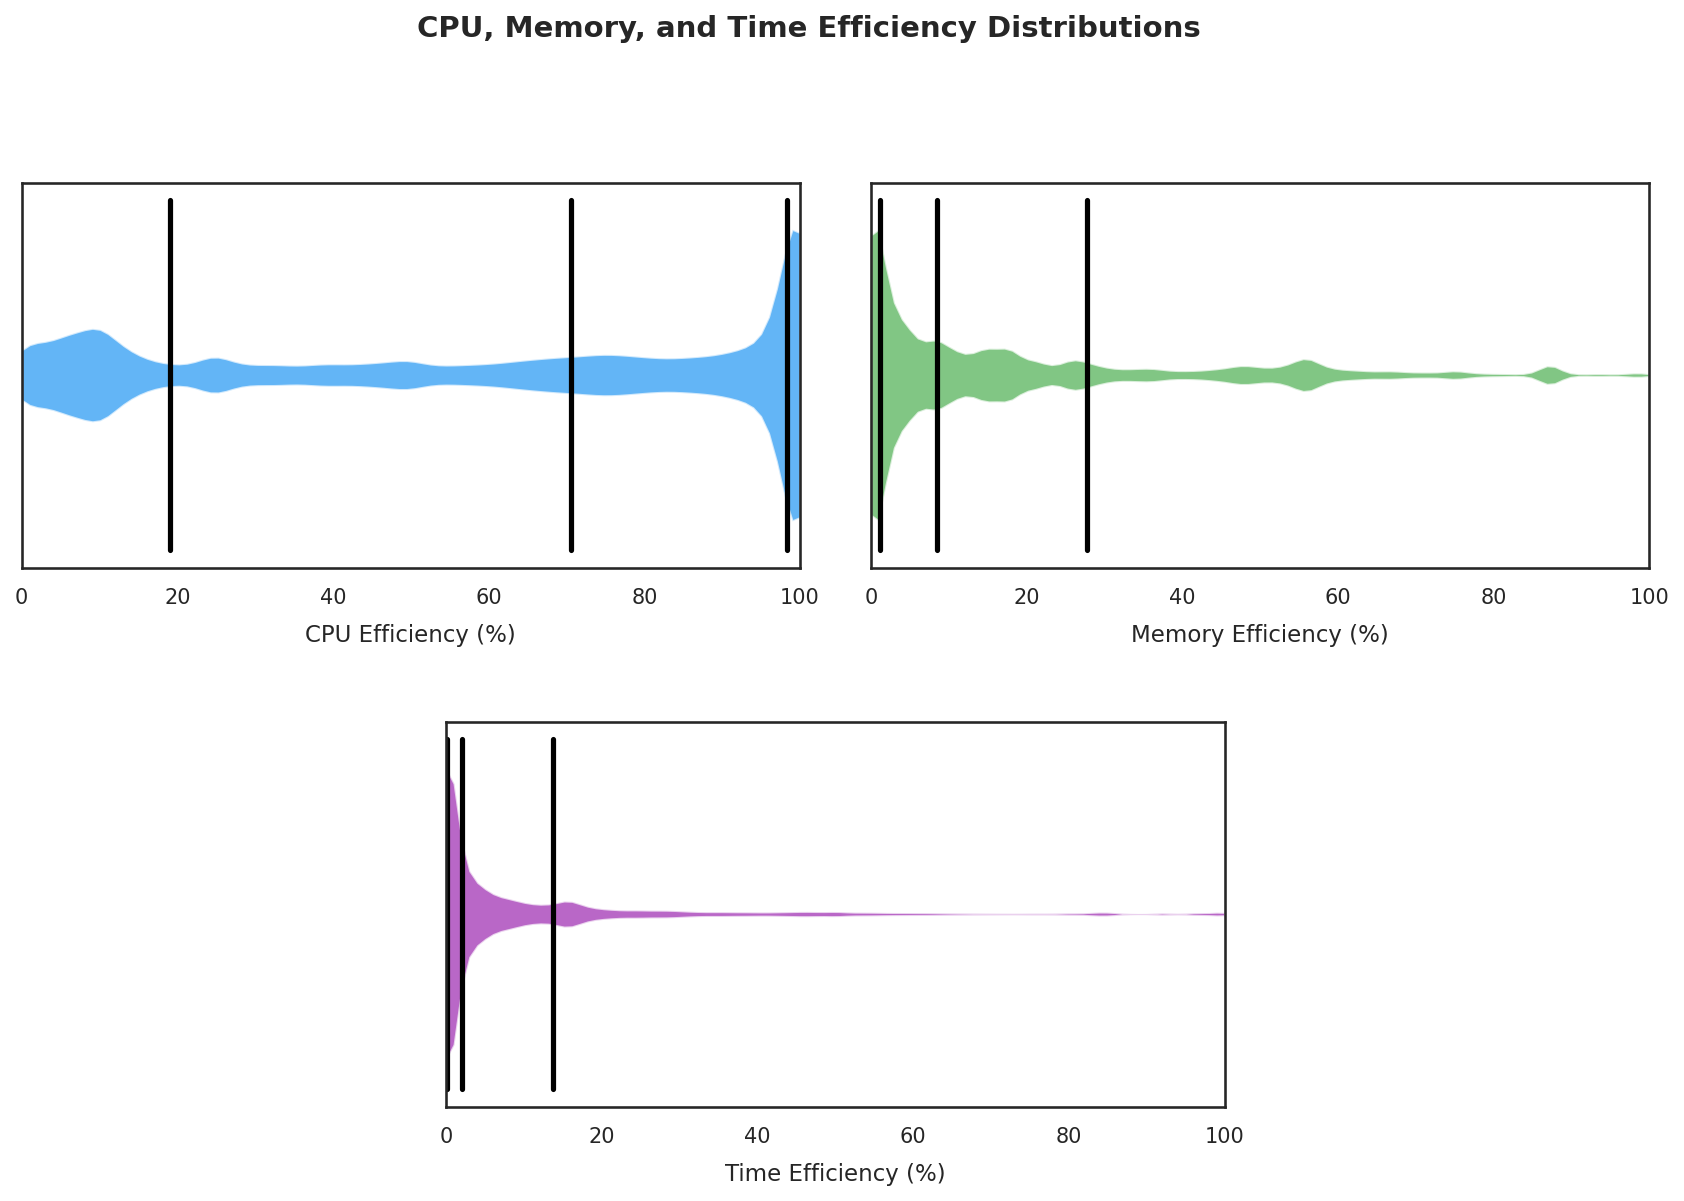

In [13]:
# Overall efficiency violin plots
cpu_data = df.loc[df['cpu_eff_req'].notna() & (df['cpu_eff_req'] <= 100), 'cpu_eff_req']
mem_data = df.loc[df['mem_eff'].notna() & (df['mem_eff'] <= 100), 'mem_eff']

# Time: exclude sentinel limits and >100%
time_data = df.loc[df['time_eff'].notna() & (df['time_eff'] <= 100)
                   & (df['timelimit_sec'] < 365 * 24 * 3600), 'time_eff']

fig = plt.figure(figsize=(14, 8))
gs = fig.add_gridspec(2, 4, hspace=0.4)
ax_cpu  = fig.add_subplot(gs[0, 0:2])
ax_mem  = fig.add_subplot(gs[0, 2:4])
ax_time = fig.add_subplot(gs[1, 1:3])

configs = [
    (ax_cpu,  cpu_data,  C_CPU,  'CPU Efficiency (%)'),
    (ax_mem,  mem_data,  C_MEM,  'Memory Efficiency (%)'),
    (ax_time, time_data, C_TIME, 'Time Efficiency (%)'),
]

for ax, data, colour, xlabel in configs:
    parts = ax.violinplot(data, positions=[0], vert=False, showmedians=False,
                          showextrema=False)
    for pc in parts['bodies']:
        pc.set_facecolor(colour)
        pc.set_alpha(0.7)
    # Draw quartile lines manually for control over thickness
    q25, q50, q75 = data.quantile([0.25, 0.5, 0.75])
    for q in [q25, q50, q75]:
        ax.plot([q, q], [-0.3, 0.3], color='black', linewidth=2.5)
    ax.set_xlabel(xlabel)
    ax.set_xlim(0, 100)
    ax.set_yticks([])

fig.suptitle('CPU, Memory, and Time Efficiency Distributions', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

  Saved cpus_requested_distribution.png


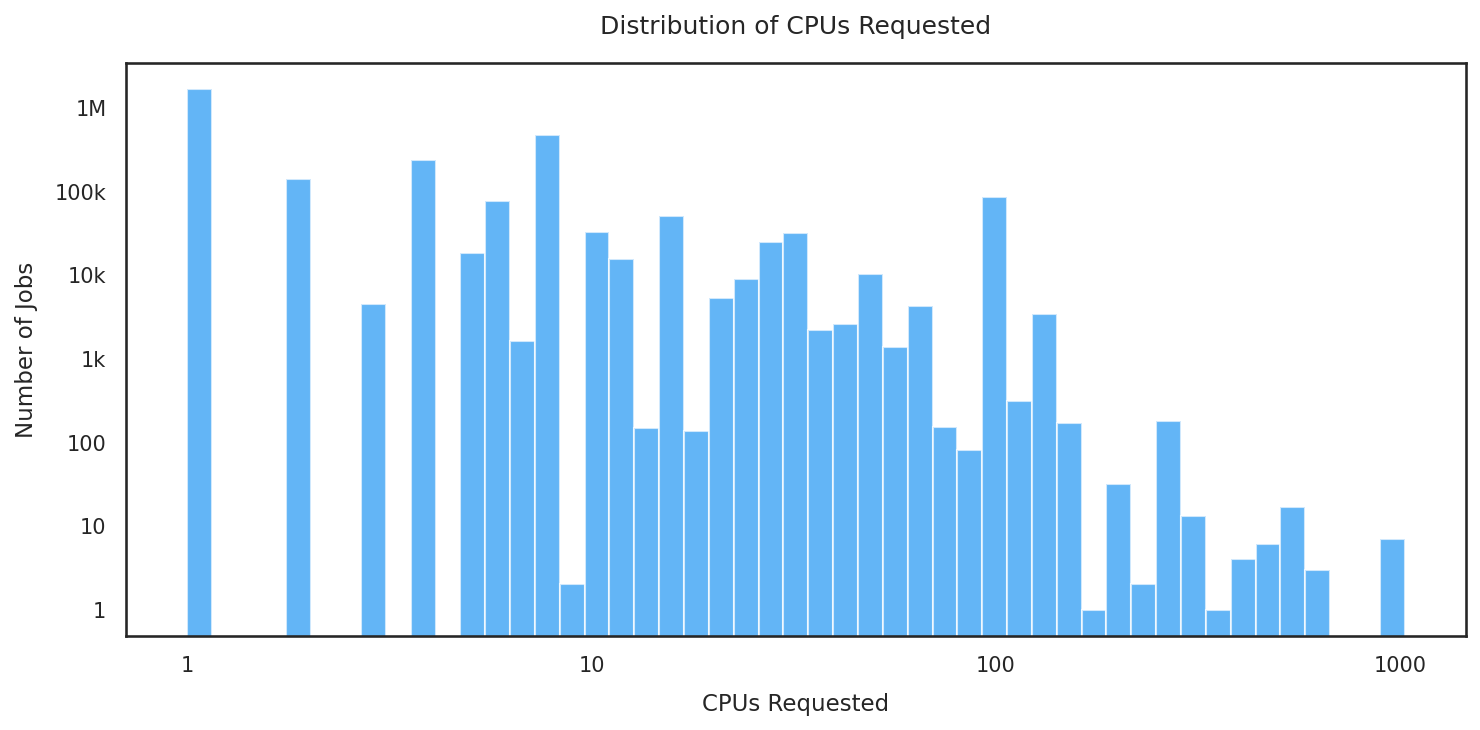


*Based on all ~2.9M efficiency jobs.*

| Stat | Value |
|------|-------|
| Median | 1 |
| Mean | 7.1 |
| 95th percentile | 28 |
| Max | 1024 |
| % requesting 1 CPU | 57.6 % |



**Top 10 most frequently requested CPU counts:**

| CPUs | Jobs | % |
|------|------|---|
| 1 | ~1.7M | 57.6 % |
| 8 | ~470k | 16.3 % |
| 4 | ~240k | 8.2 % |
| 2 | ~140k | 4.8 % |
| 100 | ~85k | 2.9 % |
| 6 | ~77k | 2.6 % |
| 16 | ~50k | 1.7 % |
| 10 | ~32k | 1.1 % |
| 28 | ~24k | 0.8 % |
| 32 | ~22k | 0.8 % |


In [14]:
cpus = df['req_cpus'].dropna()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(cpus, bins=np.logspace(0, np.log10(cpus.max()), 50),
        color=C_CPU, alpha=0.7, edgecolor='white')
ax.set_xscale('log')
ax.set_yscale('log')
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{x/1e6:.0f}M' if x >= 1e6 else
                 f'{x/1e3:.0f}k' if x >= 1e3 else f'{x:.0f}'))
ax.set_xlabel('CPUs Requested')
ax.set_ylabel('Number of Jobs')
ax.set_title('Distribution of CPUs Requested')
plt.tight_layout()
savefig('cpus_requested_distribution.png')
plt.show()

# Summary statistics
display(Markdown(f'''
*Based on all {approx(len(cpus))} efficiency jobs.*

| Stat | Value |
|------|-------|
| Median | {cpus.median():.0f} |
| Mean | {cpus.mean():.1f} |
| 95th percentile | {cpus.quantile(0.95):.0f} |
| Max | {cpus.max():.0f} |
| % requesting 1 CPU | {(cpus == 1).mean()*100:.1f} % |
'''))

# Top 10 most frequent CPU request values
top10 = cpus.value_counts().head(10).sort_values(ascending=False)
rows = []
for val, count in top10.items():
    rows.append(f'| {int(val)} | {approx(count)} | {count / len(cpus) * 100:.1f} % |')
table = '\n'.join(rows)

display(Markdown(f'''
**Top 10 most frequently requested CPU counts:**

| CPUs | Jobs | % |
|------|------|---|
{table}
'''))

  Saved memory_requested_distribution.png


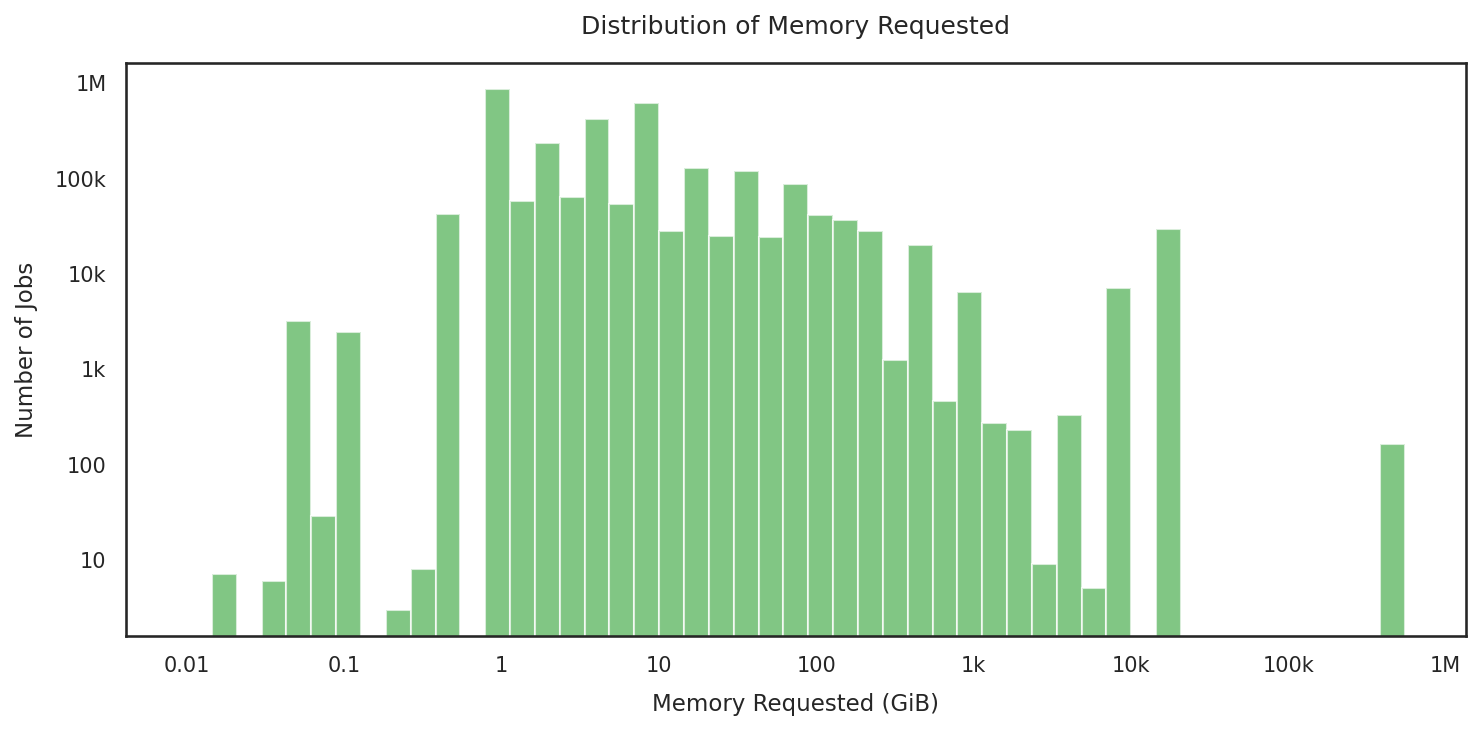


*Based on all ~2.9M efficiency jobs.*

| Stat | Value |
|------|-------|
| Median | 4.0 GiB |
| Mean | 219.3 GiB |
| 95th percentile | 100.0 GiB |
| Max | 550000 GiB |



**Top 10 most frequently requested memory amounts:**

| GiB | Jobs | % |
|-----|------|---|
| 1.0 | ~860k | 29.6 % |
| 7.8 | ~400k | 13.6 % |
| 4.0 | ~370k | 12.5 % |
| 2.0 | ~230k | 7.9 % |
| 8.0 | ~130k | 4.3 % |
| 16.0 | ~78k | 2.7 % |
| 9.8 | ~69k | 2.4 % |
| 32.0 | ~65k | 2.2 % |
| 64.0 | ~52k | 1.8 % |
| 3.9 | ~49k | 1.7 % |


In [15]:
mem_req_gib = df['reqmem_bytes'].dropna() / (1024**3)

fig, ax = plt.subplots(figsize=(10, 5))
log_bins = np.logspace(np.log10(max(0.01, mem_req_gib.min())),
                       np.log10(mem_req_gib.max()), 50)
ax.hist(mem_req_gib, bins=log_bins, color=C_MEM, alpha=0.7, edgecolor='white')
ax.set_xscale('log')
ax.set_yscale('log')
ax.xaxis.set_major_locator(mticker.LogLocator(base=10))
ax.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{x/1e6:.0f}M' if x >= 1e6 else
                 f'{x/1e3:.0f}k' if x >= 1e3 else
                 f'{x:.0f}' if x >= 1 else f'{x:.2g}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{x/1e6:.0f}M' if x >= 1e6 else
                 f'{x/1e3:.0f}k' if x >= 1e3 else f'{x:.0f}'))
ax.set_xlabel('Memory Requested (GiB)')
ax.set_ylabel('Number of Jobs')
ax.set_title('Distribution of Memory Requested')
plt.tight_layout()
savefig('memory_requested_distribution.png')
plt.show()

# Summary statistics
display(Markdown(f'''
*Based on all {approx(len(mem_req_gib))} efficiency jobs.*

| Stat | Value |
|------|-------|
| Median | {mem_req_gib.median():.1f} GiB |
| Mean | {mem_req_gib.mean():.1f} GiB |
| 95th percentile | {mem_req_gib.quantile(0.95):.1f} GiB |
| Max | {mem_req_gib.max():.0f} GiB |
'''))

# Top 10 most frequent memory request values
mem_req_rounded = mem_req_gib.round(1)
top10m = mem_req_rounded.value_counts().head(10).sort_values(ascending=False)
rows = []
for val, count in top10m.items():
    rows.append(f'| {val:.1f} | {approx(count)} | {count / len(mem_req_gib) * 100:.1f} % |')
table = '\n'.join(rows)

display(Markdown(f'''
**Top 10 most frequently requested memory amounts:**

| GiB | Jobs | % |
|-----|------|---|
{table}
'''))

In [16]:

# Extreme memory requests (>1 TiB)
TiB = 1024  # in GiB
big_mem = df[df['reqmem_bytes'].notna()].copy()
big_mem['req_gib'] = big_mem['reqmem_bytes'] / (1024**3)
big_mem['used_gib'] = big_mem['maxrss_bytes'] / (1024**3)
big_mem = big_mem[big_mem['req_gib'] > TiB]

# Debug: check mem_type values
print("mem_type value counts in >1 TiB jobs:")
print(big_mem['mem_type'].value_counts())
print()

n_big = len(big_mem)
n_per_cpu = (big_mem['mem_type'] == 'per-cpu').sum()
n_total = (big_mem['mem_type'] == 'per-node').sum()
n_users = big_mem['username'].nunique()
median_used = big_mem['used_gib'].median()

print("=== Extreme memory requests (>1 TiB) ===")
print(f"Total jobs:           {n_big:,}")
print(f"Using --mem-per-cpu:  {n_per_cpu:,} ({n_per_cpu/n_big*100:.1f}%)")
print(f"Using --mem (total):  {n_total:,} ({n_total/n_big*100:.1f}%)")
print(f"Unique users:         {n_users}")
print(f"Median actual usage:  {median_used:.2f} GiB")

# Per-CPU value distribution for --mem-per-cpu jobs
per_cpu_big = big_mem[big_mem['mem_type'] == 'per-cpu'].copy()
if len(per_cpu_big) > 0:
    per_cpu_big['gib_per_cpu'] = per_cpu_big['req_gib'] / per_cpu_big['req_cpus']
    print(f"\nMost common --mem-per-cpu values (GiB/CPU) for >1 TiB jobs:")
    top_vals = per_cpu_big['gib_per_cpu'].value_counts().head(5)
    for val, count in top_vals.items():
        print(f"  {val:.1f} GiB/CPU: {count:,} jobs")


mem_type value counts in >1 TiB jobs:
mem_type
per-cpu     37272
per-node      157
Name: count, dtype: int64

=== Extreme memory requests (>1 TiB) ===
Total jobs:           37,429
Using --mem-per-cpu:  37,272 (99.6%)
Using --mem (total):  157 (0.4%)
Unique users:         25
Median actual usage:  0.85 GiB

Most common --mem-per-cpu values (GiB/CPU) for >1 TiB jobs:
  150.0 GiB/CPU: 36,381 jobs
  78.1 GiB/CPU: 326 jobs
  31.2 GiB/CPU: 171 jobs
  2200.0 GiB/CPU: 161 jobs
  25.0 GiB/CPU: 112 jobs


  Saved time_requested_distribution.png


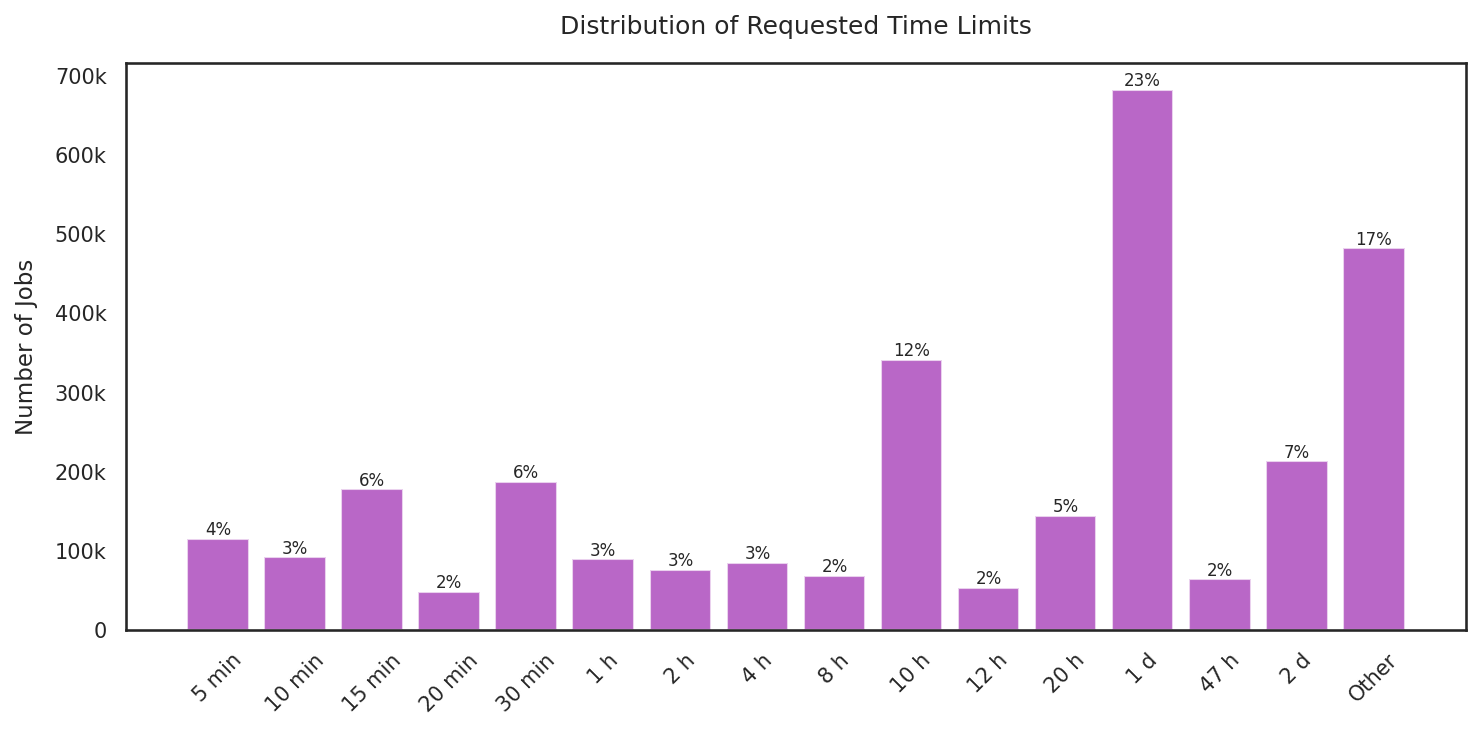


*Each bar shows the exact count of jobs requesting that specific time limit.
Based on all ~2.9M efficiency jobs.*

| Stat | Value |
|------|-------|
| Median | 10 h |
| Mean | 198227.2 h |
| 95th percentile | 2 d |
| Max | 71582788.2 h |
| % requesting ≤ 1 h | 31.0 % |
| % requesting ≤ 24 h | 87.3 % |

Over-requesting time does not block resources after a job finishes — the
scheduler releases CPUs and memory immediately. However, requesting more time than
needed **increases queue wait time**, because the scheduler must find a
slot where resources are free for the full requested duration.


In [17]:
time_req = df['timelimit_sec'].dropna()
time_req_min = (time_req / 60).round(0)  # round to nearest minute to avoid artifacts

def fmt_timelimit_min(minutes):
    """Convert minutes to a readable label. Only use 'd' for exact multiples of 24 h."""
    if minutes < 1:
        return f'{minutes*60:.0f} s'
    if minutes < 60:
        return f'{minutes:.0f} min'
    hrs = minutes / 60
    if hrs < 24:
        return f'{hrs:.0f} h' if hrs == int(hrs) else f'{hrs:.1f} h'
    # Only use day format for exact multiples of 24 hours
    if minutes % 1440 == 0:
        d = int(minutes // 1440)
        return f'{d} d'
    # Otherwise show in hours
    return f'{hrs:.0f} h' if hrs == int(hrs) else f'{hrs:.1f} h'

# Each bar = exact count of jobs requesting that specific time limit
counts = time_req_min.value_counts().sort_values(ascending=False)
top_n = 15
top = counts.head(top_n)
other_count = counts.iloc[top_n:].sum() if len(counts) > top_n else 0

# Sort by time limit value (ascending) for natural reading order
top = top.reindex(sorted(top.index))

labels = [fmt_timelimit_min(v) for v in top.index]
values = top.values
if other_count > 0:
    labels.append('Other')
    values = np.append(values, other_count)

total = len(time_req_min)
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(range(len(labels)), values, color='#9C27B0', alpha=0.7, edgecolor='white')
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha='center')

# Linear y-axis with readable formatting
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else
                 f'{x/1e3:.0f}k' if x >= 1e3 else f'{x:.0f}'))

ax.set_ylabel('Number of Jobs')
ax.set_title('Distribution of Requested Time Limits')

# Annotate bars with percentages only
for bar, v in zip(bars, values):
    pct = v / total * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f'{pct:.0f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
savefig('time_requested_distribution.png')
plt.show()

time_req_hrs = time_req / 3600
display(Markdown(f'''
*Each bar shows the exact count of jobs requesting that specific time limit.
Based on all {approx(len(time_req))} efficiency jobs.*

| Stat | Value |
|------|-------|
| Median | {fmt_timelimit_min(time_req_min.median())} |
| Mean | {fmt_timelimit_min(time_req_min.mean())} |
| 95th percentile | {fmt_timelimit_min(time_req_min.quantile(0.95))} |
| Max | {fmt_timelimit_min(time_req_min.max())} |
| % requesting ≤ 1 h | {(time_req_hrs <= 1).mean()*100:.1f} % |
| % requesting ≤ 24 h | {(time_req_hrs <= 24).mean()*100:.1f} % |

Over-requesting time does not block resources after a job finishes — the
scheduler releases CPUs and memory immediately. However, requesting more time than
needed **increases queue wait time**, because the scheduler must find a
slot where resources are free for the full requested duration.
'''))

  Saved time_requested_distribution_binned.png


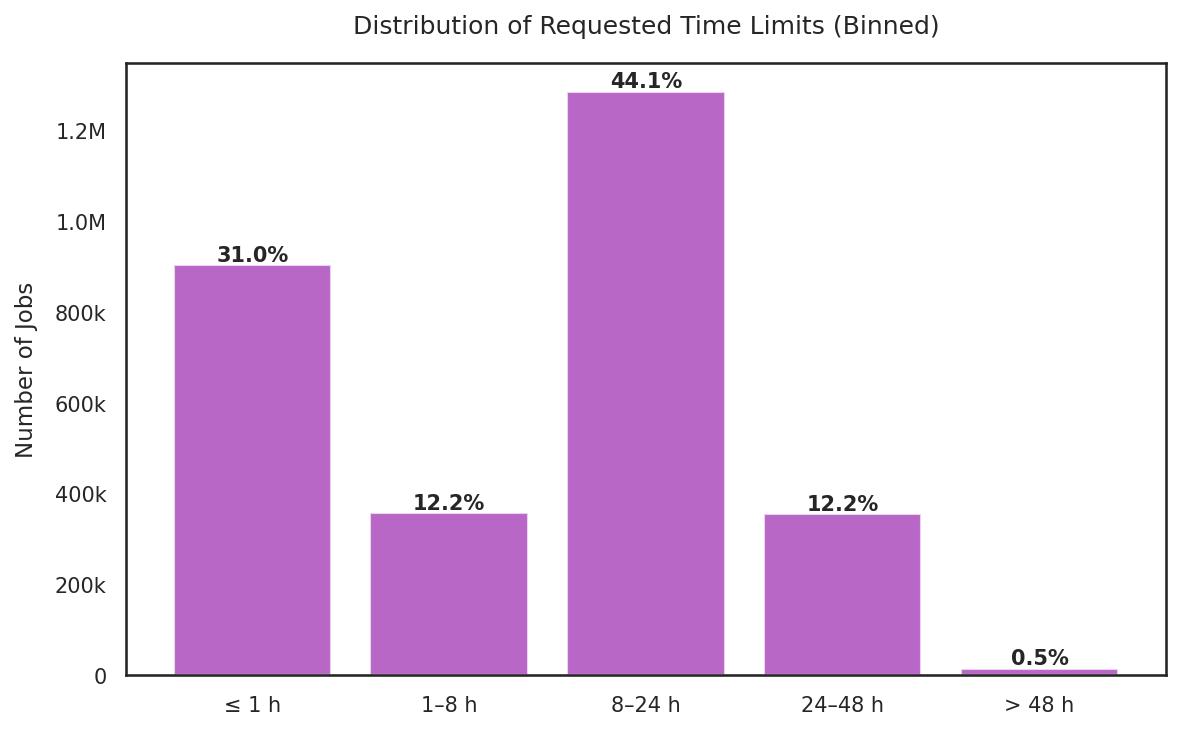

*Based on all ~2.9M efficiency jobs.*

In [18]:
# Binned time distribution (simpler view for blog post)
time_req_hrs = df['timelimit_sec'].dropna() / 3600

bin_edges = [0, 1, 8, 24, 48, np.inf]
bin_labels = ['\u2264 1 h', '1\u20138 h', '8\u201324 h', '24\u201348 h', '> 48 h']
binned = pd.cut(time_req_hrs, bins=bin_edges, labels=bin_labels, right=True)
bin_counts = binned.value_counts().reindex(bin_labels)

total = bin_counts.sum()
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(range(len(bin_labels)), bin_counts.values,
              color='#9C27B0', alpha=0.7, edgecolor='white')
ax.set_xticks(range(len(bin_labels)))
ax.set_xticklabels(bin_labels)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else
                 f'{x/1e3:.0f}k' if x >= 1e3 else f'{x:.0f}'))

ax.set_ylabel('Number of Jobs')
ax.set_title('Distribution of Requested Time Limits (Binned)')

for bar, v in zip(bars, bin_counts.values):
    pct = v / total * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=10,
            fontweight='bold')

plt.tight_layout()
savefig('time_requested_distribution_binned.png')
plt.show()

display(Markdown(f'*Based on all {approx(int(total))} efficiency jobs.*'))

  Saved wait_time_distribution.png


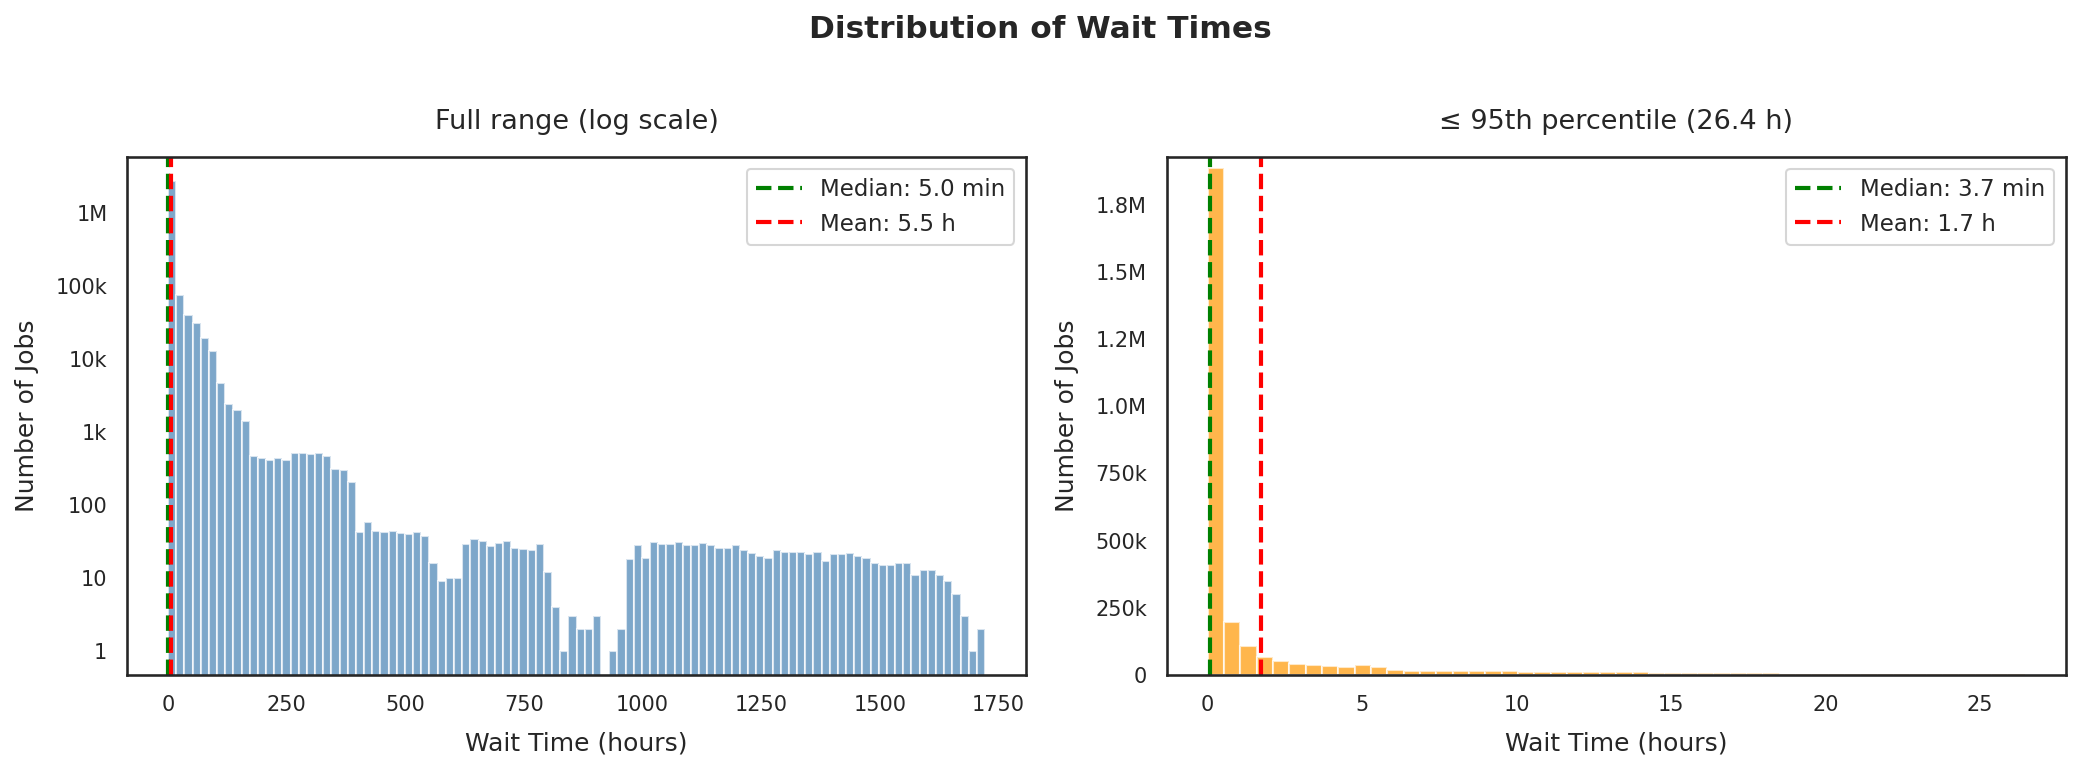


*Based on **~2.9M** jobs.
Most jobs (95 %) wait less than
**26.4 hours**. The median wait is **5.0 minutes**.*

| Stat | All jobs | ≤ 95th pctl |
|------|----------|-------------|
| Median | 5.0 min | 3.7 min |
| Mean | 5.5 h (331.7 min) | 1.7 h (103.8 min) |
| Max | 1722 h | 26.4 h |


In [19]:
wait_data = df['wait_sec'].dropna()
wait_hours = wait_data / 3600

median_w = wait_hours.median()
mean_w = wait_hours.mean()
p95_w = wait_hours.quantile(0.95)
median_min = median_w * 60
mean_min = mean_w * 60

# Zoomed subset and its own stats
zoomed = wait_hours[wait_hours <= p95_w]
median_z = zoomed.median()
mean_z = zoomed.mean()
median_z_min = median_z * 60
mean_z_min = mean_z * 60

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: full range, log scale
axes[0].hist(wait_hours, bins=100, color='steelblue', alpha=0.7, edgecolor='white')
axes[0].axvline(median_w, color='green', linestyle='--', linewidth=2,
                label=f'Median: {median_min:.1f} min')
axes[0].axvline(mean_w, color='red', linestyle='--', linewidth=2,
                label=f'Mean: {mean_w:.1f} h')
axes[0].set_xlabel('Wait Time (hours)', fontsize=12)
axes[0].set_ylabel('Number of Jobs', fontsize=12)
axes[0].set_title('Full range (log scale)', fontsize=13)
axes[0].set_yscale('log')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{x/1e6:.0f}M' if x >= 1e6 else
                 f'{x/1e3:.0f}k' if x >= 1e3 else f'{x:.0f}'))
axes[0].legend()

# Right: zoomed to 95th percentile — stats from zoomed subset
axes[1].hist(zoomed, bins=50, color='#FF9800', alpha=0.7, edgecolor='white')
axes[1].axvline(median_z, color='green', linestyle='--', linewidth=2,
                label=f'Median: {median_z_min:.1f} min')
axes[1].axvline(mean_z, color='red', linestyle='--', linewidth=2,
                label=f'Mean: {mean_z:.1f} h')
axes[1].set_xlabel('Wait Time (hours)', fontsize=12)
axes[1].set_ylabel('Number of Jobs', fontsize=12)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else
                 f'{x/1e3:.0f}k' if x >= 1e3 else f'{x:.0f}'))
axes[1].margins(y=0.02)
axes[1].set_title(f'\u2264 95th percentile ({p95_w:.1f} h)', fontsize=13)
axes[1].legend()

fig.suptitle('Distribution of Wait Times',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
savefig('wait_time_distribution.png')
plt.show()

display(Markdown(f'''
*Based on **{approx(len(wait_hours))}** jobs.
Most jobs ({len(zoomed)/len(wait_hours)*100:.0f} %) wait less than
**{p95_w:.1f} hours**. The median wait is **{median_min:.1f} minutes**.*

| Stat | All jobs | ≤ 95th pctl |
|------|----------|-------------|
| Median | {median_min:.1f} min | {median_z_min:.1f} min |
| Mean | {mean_w:.1f} h ({mean_min:.1f} min) | {mean_z:.1f} h ({mean_z_min:.1f} min) |
| Max | {wait_hours.max():.0f} h | {p95_w:.1f} h |
'''))


  Saved nodes_distribution.png


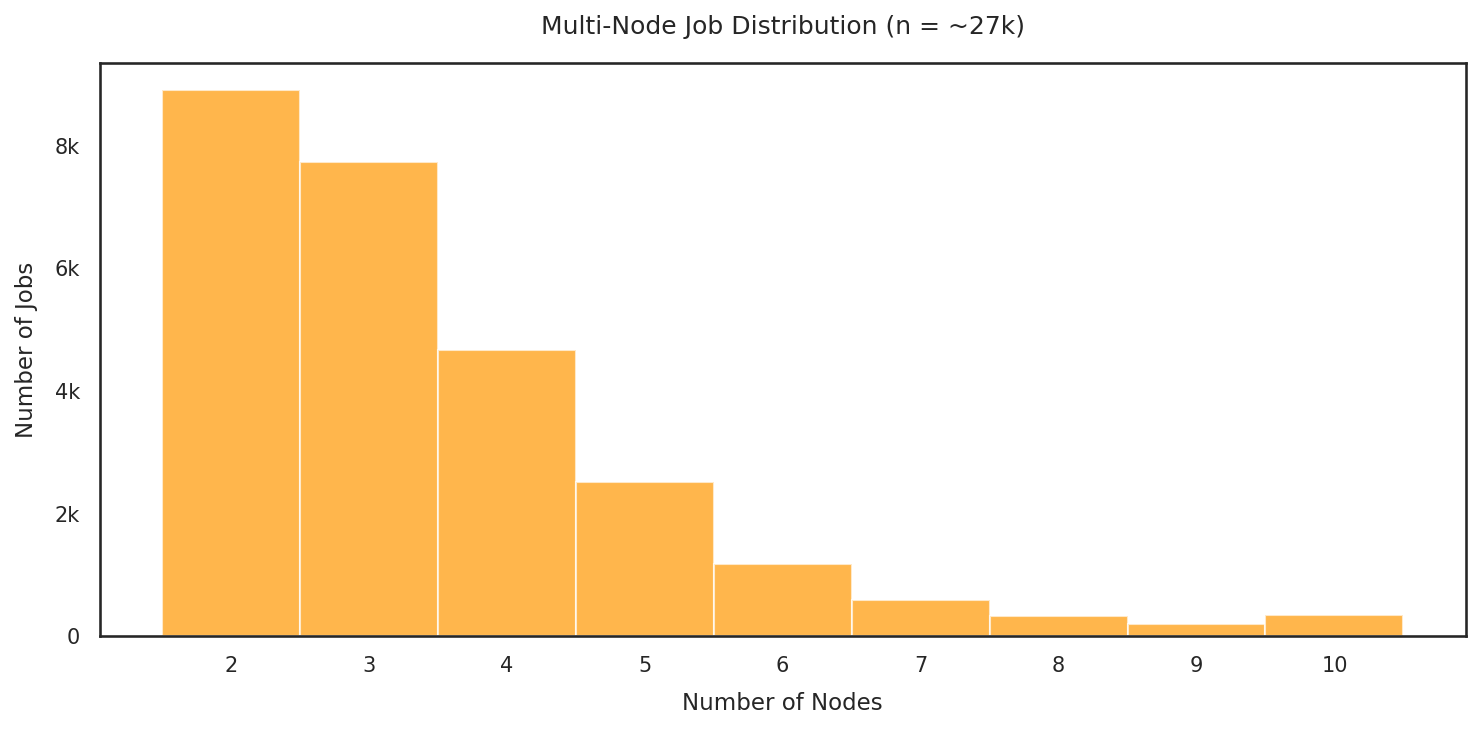


*Based on **~2.9M** jobs.
**~2.9M** (99.1 %) used a single node and
**~27k** (0.9 %) used multiple nodes.
The plot above shows only the multi-node distribution (up to the 99th
percentile).*

| Stat | Value |
|------|-------|
| Median | 1 |
| Mean | 1.02 |
| Max | 20 |
| % single-node | 99.1 % |


In [20]:
nodes = pd.to_numeric(df['n_nodes'], errors='coerce').dropna()
nodes = nodes[nodes > 0]

n_single = (nodes == 1).sum()
n_multi = (nodes > 1).sum()
pct_single = n_single / len(nodes) * 100

# Only plot multi-node distribution
multi = nodes[nodes > 1]

fig, ax = plt.subplots(figsize=(10, 5))
if len(multi) > 0:
    top_multi = int(multi.quantile(0.99)) if len(multi) > 10 else int(multi.max())
    ax.hist(multi[multi <= top_multi], bins=range(2, top_multi + 2),
            color='#FF9800', alpha=0.7, edgecolor='white')
    # Center x-tick labels on each bar (bars span [n, n+1), center at n+0.5)
    ax.set_xticks([n + 0.5 for n in range(2, top_multi + 1)])
    ax.set_xticklabels([str(n) for n in range(2, top_multi + 1)])
    ax.set_xlabel('Number of Nodes')
    ax.set_ylabel('Number of Jobs')
    ax.yaxis.set_major_formatter(COUNT_FMT)
    ax.set_title(f'Multi-Node Job Distribution (n = {approx(n_multi)})')
else:
    ax.text(0.5, 0.5, 'No multi-node jobs', transform=ax.transAxes,
            ha='center', fontsize=14)

plt.tight_layout()
savefig('nodes_distribution.png')
plt.show()

display(Markdown(f'''
*Based on **{approx(len(nodes))}** jobs.
**{approx(n_single)}** ({pct_single:.1f} %) used a single node and
**{approx(n_multi)}** ({100 - pct_single:.1f} %) used multiple nodes.
The plot above shows only the multi-node distribution (up to the 99th
percentile).*

| Stat | Value |
|------|-------|
| Median | {nodes.median():.0f} |
| Mean | {nodes.mean():.2f} |
| Max | {nodes.max():.0f} |
| % single-node | {pct_single:.1f} % |
'''))

  Saved severity_barplot.png


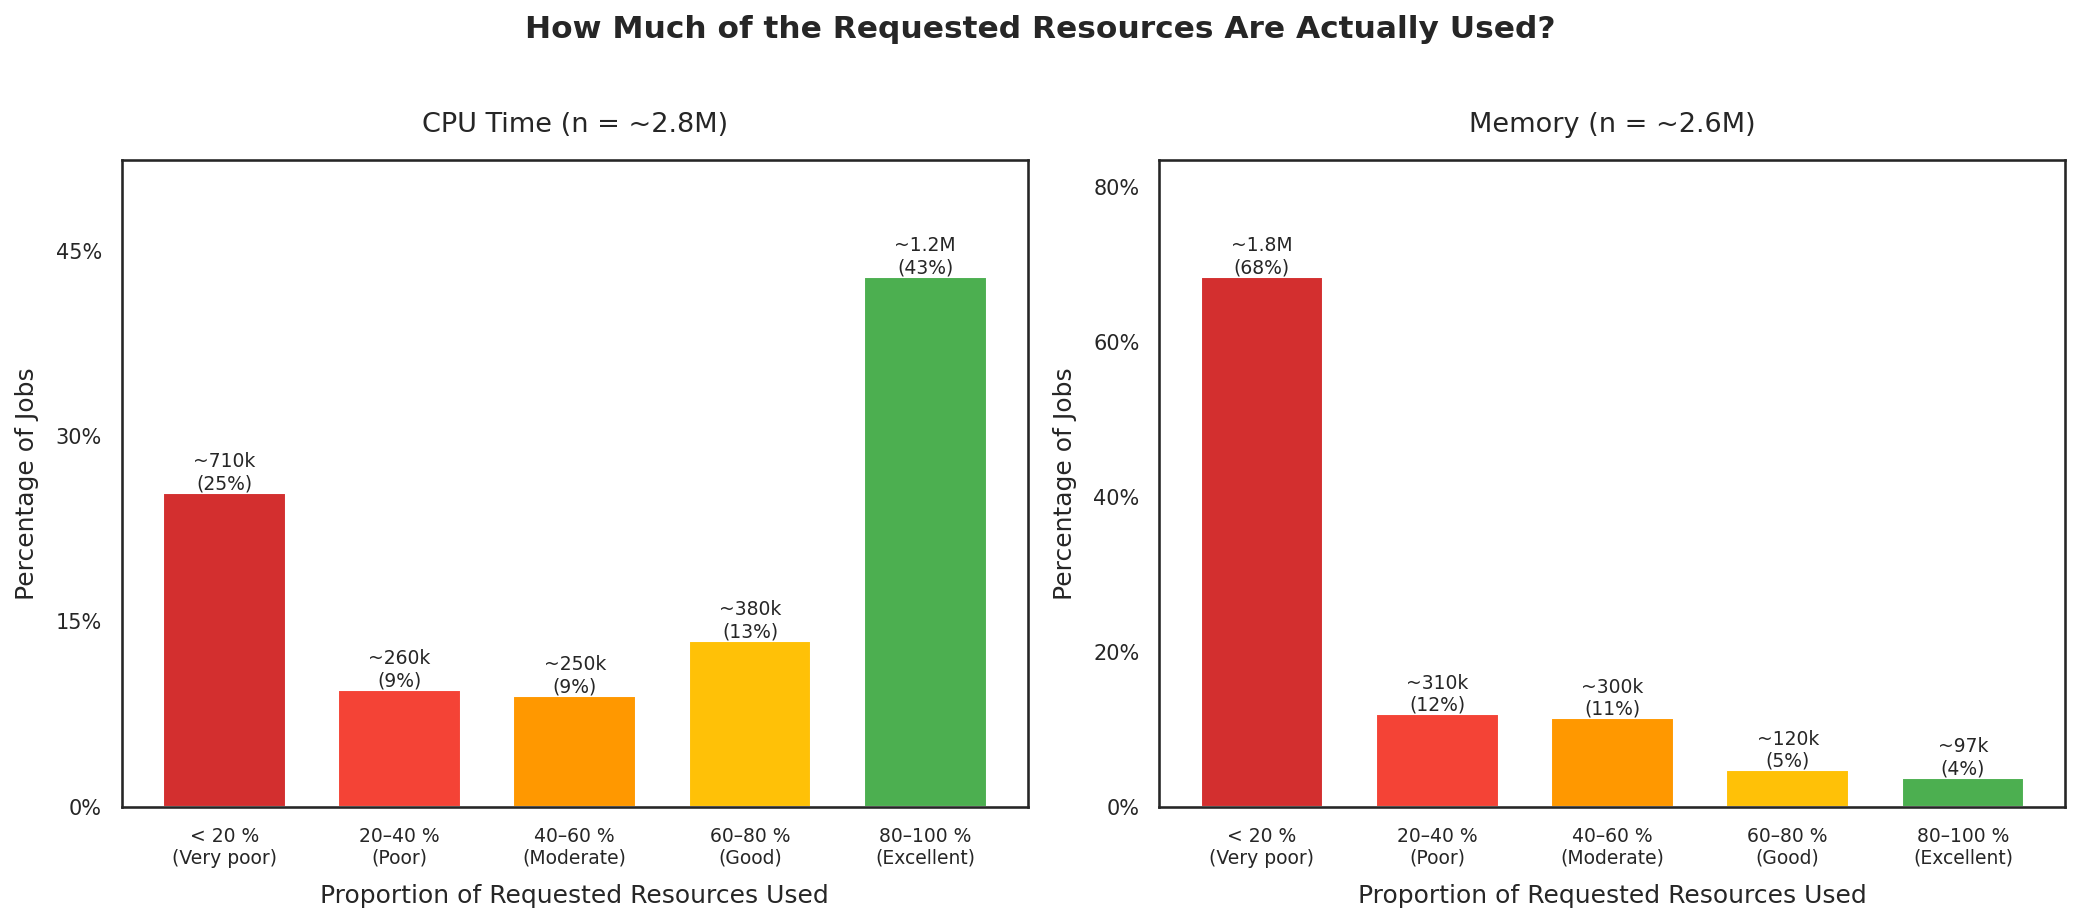

=== Subgroup severity (< 20 %, 'very poor') ===
Multi-CPU jobs:  624,457 of 1,226,090 (51%)
Multi-GB jobs:   1,314,054 of 1,906,835 (69%)



*Each bar shows the percentage of jobs whose efficiency falls into that range.
The label on each bar shows the approximate job count and percentage.*

*Note on sample sizes:* The number of jobs in these plots differs from the
resource distribution plots above. The resource distributions show **all**
~2.9M efficiency jobs. These severity plots only include jobs with a
**valid** efficiency value **≤ 100 %**. Of the ~2.9M jobs
with a non-null CPU efficiency, ~97k had efficiency > 100 % and
are excluded here. Jobs with null efficiency (e.g., zero elapsed time) are
also excluded.

CPU and memory efficiencies are filtered **independently** — a job can appear
in the CPU plot but not the memory plot, or vice versa.


In [21]:
bins   = [0, 20, 40, 60, 80, 100.01]   # 100.01 to include exactly 100
labels = ['< 20 %\n(Very poor)', '20\u201340 %\n(Poor)', '40\u201360 %\n(Moderate)',
          '60\u201380 %\n(Good)', '80\u2013100 %\n(Excellent)']
colors = ['#D32F2F', '#F44336', '#FF9800', '#FFC107', '#4CAF50']

cpu_filt = df['cpu_eff_req'].dropna()
cpu_filt = cpu_filt[cpu_filt <= 100]
mem_filt = df['mem_eff'].dropna()
mem_filt = mem_filt[mem_filt <= 100]

cpu_bins = pd.cut(cpu_filt, bins=bins, labels=labels, right=False)
mem_bins = pd.cut(mem_filt, bins=bins, labels=labels, right=False)

cpu_counts = cpu_bins.value_counts().reindex(labels, fill_value=0)
mem_counts = mem_bins.value_counts().reindex(labels, fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, counts, resource, n in [
    (axes[0], cpu_counts, 'CPU Time', len(cpu_filt)),
    (axes[1], mem_counts, 'Memory', len(mem_filt)),
]:
    pcts = counts.values / n * 100
    bars = ax.bar(range(len(labels)), pcts, color=colors, edgecolor='white', width=0.7)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_xlabel('Proportion of Requested Resources Used', fontsize=12)
    ax.set_ylabel('Percentage of Jobs', fontsize=12)
    ax.set_ylim(0, max(pcts) * 1.22)
    ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=5))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
    ax.set_title(f'{resource} (n = {approx(n)})', fontsize=13)
    for bar, v, pct in zip(bars, counts.values, pcts):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                f'{approx(v)}\n({pct:.0f}%)', ha='center', va='bottom', fontsize=9)

fig.suptitle('How Much of the Requested Resources Are Actually Used?',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
savefig('severity_barplot.png')
plt.show()

# --- Severity breakdown for subgroups ---
# Multi-CPU jobs
multi_cpu_eff = df.loc[df['req_cpus'] > 1, 'cpu_eff_req'].dropna()
multi_cpu_le100 = multi_cpu_eff[multi_cpu_eff <= 100]
multi_cpu_very_poor = (multi_cpu_le100 < 20).sum()

# Multi-GB memory jobs (>1 GiB)
df_with_mem = df[df['reqmem_bytes'].notna()].copy()
df_with_mem['reqmem_gib'] = df_with_mem['reqmem_bytes'] / (1024**3)
multi_gb_eff = df_with_mem.loc[df_with_mem['reqmem_gib'] > 1, 'mem_eff'].dropna()
multi_gb_le100 = multi_gb_eff[multi_gb_eff <= 100]
multi_gb_very_poor = (multi_gb_le100 < 20).sum()

print("=== Subgroup severity (< 20 %, 'very poor') ===")
print(f"Multi-CPU jobs:  {multi_cpu_very_poor:,} of {len(multi_cpu_le100):,} "
      f"({multi_cpu_very_poor / len(multi_cpu_le100) * 100:.0f}%)")
print(f"Multi-GB jobs:   {multi_gb_very_poor:,} of {len(multi_gb_le100):,} "
      f"({multi_gb_very_poor / len(multi_gb_le100) * 100:.0f}%)")

n_cpu_all = df['req_cpus'].notna().sum()
n_cpu_valid_eff = df['cpu_eff_req'].notna().sum()
n_cpu_over100 = (df['cpu_eff_req'] > 100).sum()

display(Markdown(f'''
*Each bar shows the percentage of jobs whose efficiency falls into that range.
The label on each bar shows the approximate job count and percentage.*

*Note on sample sizes:* The number of jobs in these plots differs from the
resource distribution plots above. The resource distributions show **all**
{approx(n_cpu_all)} efficiency jobs. These severity plots only include jobs with a
**valid** efficiency value **\u2264 100 %**. Of the {approx(n_cpu_valid_eff)} jobs
with a non-null CPU efficiency, {approx(n_cpu_over100)} had efficiency > 100 % and
are excluded here. Jobs with null efficiency (e.g., zero elapsed time) are
also excluded.

CPU and memory efficiencies are filtered **independently** — a job can appear
in the CPU plot but not the memory plot, or vice versa.
'''))

  Saved cpu_requested_vs_used.png


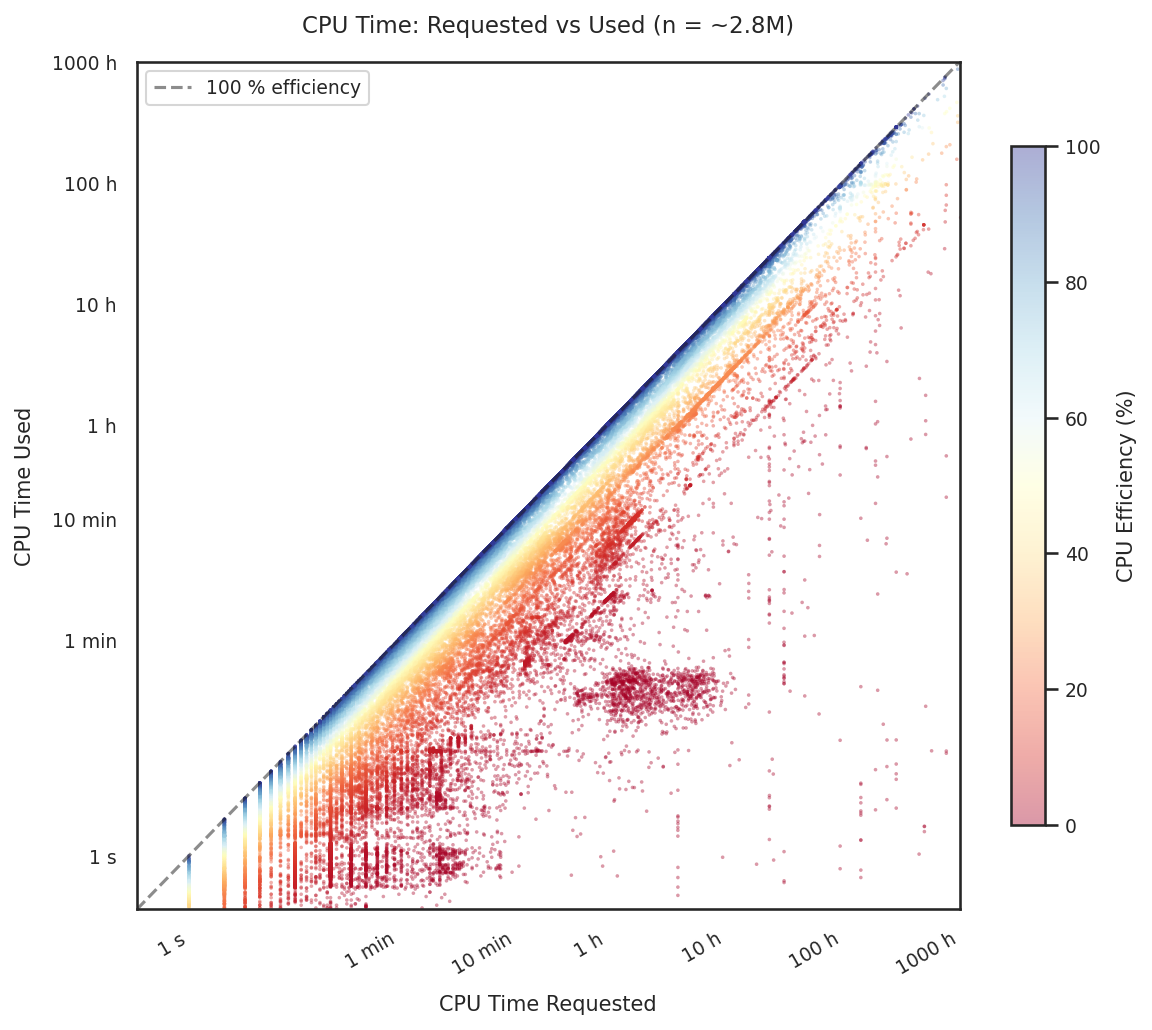

In [22]:
scatter_df = df[['elapsed_sec', 'req_cpus', 'total_cpu_sec',
                  'cpu_eff_req']].dropna()
scatter_df = scatter_df[scatter_df['cpu_eff_req'] <= 100]
scatter_df['cpu_req_hrs'] = (scatter_df['elapsed_sec']
                             * scatter_df['req_cpus'] / 3600)
scatter_df['cpu_used_hrs'] = scatter_df['total_cpu_sec'] / 3600
scatter_df['eff'] = scatter_df['cpu_eff_req']

# Filter out zeros/near-zeros for log scale
scatter_df = scatter_df[(scatter_df['cpu_req_hrs'] > 1e-4)
                        & (scatter_df['cpu_used_hrs'] > 1e-4)]

# Subsample for scatter plot
sample = scatter_df.sample(min(80_000, len(scatter_df)), random_state=42)

# Same range for both axes so the diagonal goes corner-to-corner
all_vals = pd.concat([scatter_df['cpu_req_hrs'], scatter_df['cpu_used_hrs']])
lo = 10 ** np.floor(np.log10(all_vals.quantile(0.001)))
hi = 10 ** np.ceil(np.log10(all_vals.quantile(0.999)))

# Human-readable ticks covering both requested and used ranges
_cpu_ticks = [
    (1/3600, '1 s'), (1/60, '1 min'), (10/60, '10 min'),
    (1, '1 h'), (10, '10 h'), (100, '100 h'), (1000, '1000 h'),
]
visible = [(v, l) for v, l in _cpu_ticks if lo <= v <= hi]

fig, ax = plt.subplots(figsize=(8, 7))
sc = ax.scatter(sample['cpu_req_hrs'], sample['cpu_used_hrs'],
                c=sample['eff'], cmap='RdYlBu', vmin=0, vmax=100,
                s=3, alpha=0.4, edgecolors='none', rasterized=True)
cbar = fig.colorbar(sc, ax=ax, shrink=0.8)
cbar.set_label('CPU Efficiency (%)', fontsize=10)
cbar.ax.tick_params(labelsize=9)

ax.plot([lo, hi], [lo, hi], 'k--', lw=1.5, alpha=0.5, label='100 % efficiency')

ax.set_xlabel('CPU Time Requested', fontsize=10)
ax.set_ylabel('CPU Time Used', fontsize=10)
ax.set_title(f'CPU Time: Requested vs Used (n = {approx(len(scatter_df))})', fontsize=11)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.tick_params(labelsize=9)

if visible:
    tick_vals, tick_labels = zip(*visible)
    ax.set_xticks(tick_vals)
    ax.set_xticklabels(tick_labels, fontsize=9, rotation=30, ha='right')
    ax.set_yticks(tick_vals)
    ax.set_yticklabels(tick_labels, fontsize=9)
ax.xaxis.set_minor_locator(mticker.NullLocator())
ax.yaxis.set_minor_locator(mticker.NullLocator())

ax.legend(fontsize=9)
plt.tight_layout()
savefig('cpu_requested_vs_used.png')
plt.show()

  Saved mem_requested_vs_used.png


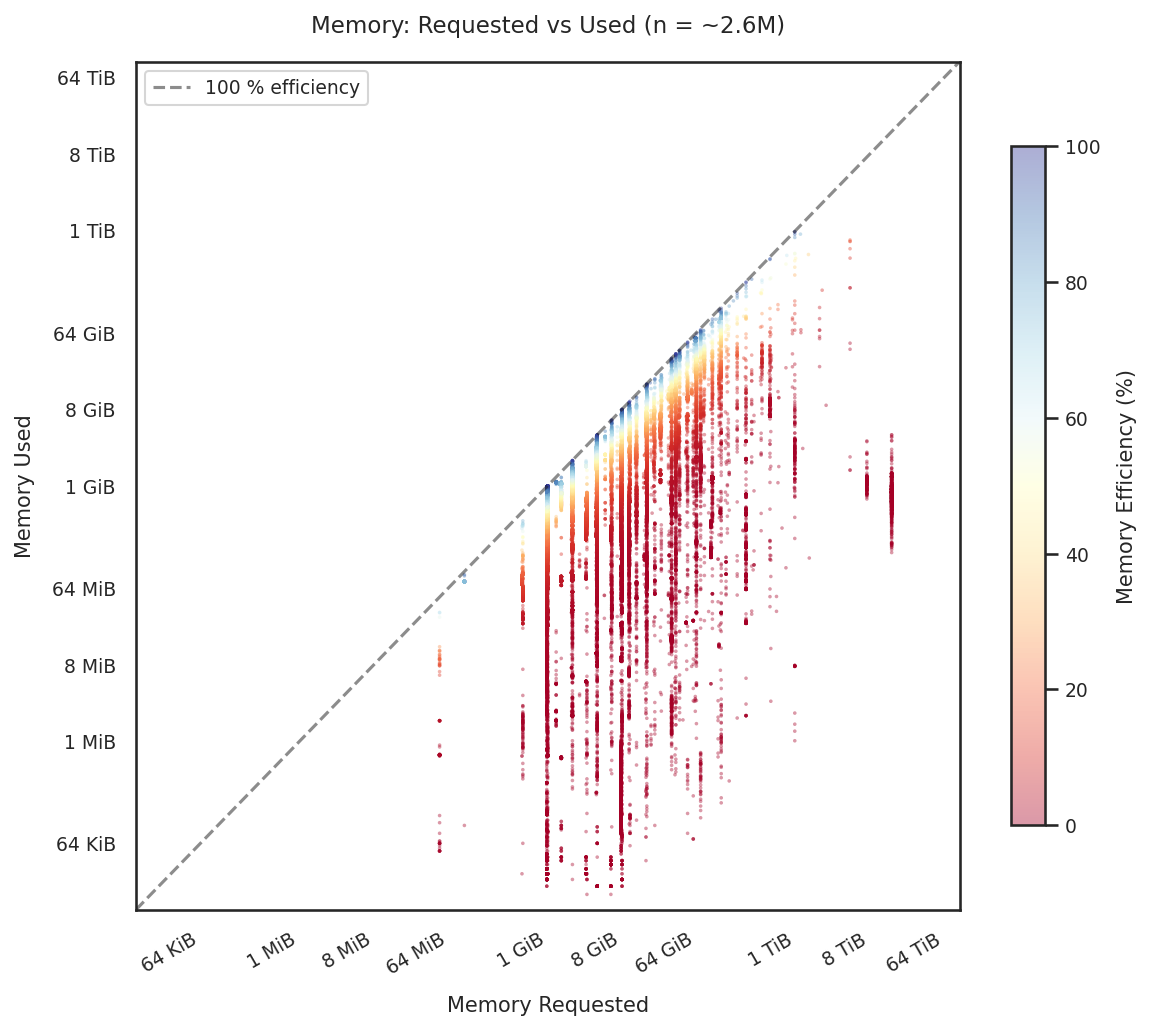

In [23]:
mem_sc = df[['reqmem_bytes', 'maxrss_bytes', 'mem_eff']].dropna()
mem_sc = mem_sc[mem_sc['mem_eff'] <= 100]
mem_sc['req_gib']  = mem_sc['reqmem_bytes'] / (1024**3)
mem_sc['used_gib'] = mem_sc['maxrss_bytes'] / (1024**3)
mem_sc['eff'] = mem_sc['mem_eff']

# Filter out zeros for log scale
mem_sc = mem_sc[(mem_sc['req_gib'] > 0) & (mem_sc['used_gib'] > 0)]

# Subsample for scatter plot
sample = mem_sc.sample(min(80_000, len(mem_sc)), random_state=42)

# Same range for both axes so the diagonal goes corner-to-corner
all_vals = pd.concat([mem_sc['req_gib'], mem_sc['used_gib']])
lo = 10 ** np.floor(np.log10(all_vals.quantile(0.001)))
hi = 10 ** np.ceil(np.log10(all_vals.quantile(0.999)))

# Binary ticks covering both requested and used ranges
_mem_ticks = [
    (1/1024/16, '64 KiB'),
    (1/1024, '1 MiB'), (1/128, '8 MiB'), (1/16, '64 MiB'),
    (1, '1 GiB'), (8, '8 GiB'), (64, '64 GiB'),
    (1024, '1 TiB'), (8*1024, '8 TiB'), (64*1024, '64 TiB'),
]
visible = [(v, l) for v, l in _mem_ticks if lo <= v <= hi]

fig, ax = plt.subplots(figsize=(8, 7))
sc = ax.scatter(sample['req_gib'], sample['used_gib'],
                c=sample['eff'], cmap='RdYlBu', vmin=0, vmax=100,
                s=3, alpha=0.4, edgecolors='none', rasterized=True)
cbar = fig.colorbar(sc, ax=ax, shrink=0.8)
cbar.set_label('Memory Efficiency (%)', fontsize=10)
cbar.ax.tick_params(labelsize=9)

ax.plot([lo, hi], [lo, hi], 'k--', lw=1.5, alpha=0.5, label='100 % efficiency')

ax.set_xlabel('Memory Requested', fontsize=10)
ax.set_ylabel('Memory Used', fontsize=10)
ax.set_title(f'Memory: Requested vs Used (n = {approx(len(mem_sc))})', fontsize=11)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.tick_params(labelsize=9)

if visible:
    tick_vals, tick_labels = zip(*visible)
    ax.set_xticks(tick_vals)
    ax.set_xticklabels(tick_labels, fontsize=9, rotation=30, ha='right')
    ax.set_yticks(tick_vals)
    ax.set_yticklabels(tick_labels, fontsize=9)
ax.xaxis.set_minor_locator(mticker.NullLocator())
ax.yaxis.set_minor_locator(mticker.NullLocator())

ax.legend(fontsize=9)
plt.tight_layout()
savefig('mem_requested_vs_used.png')
plt.show()

  Saved time_requested_vs_used.png


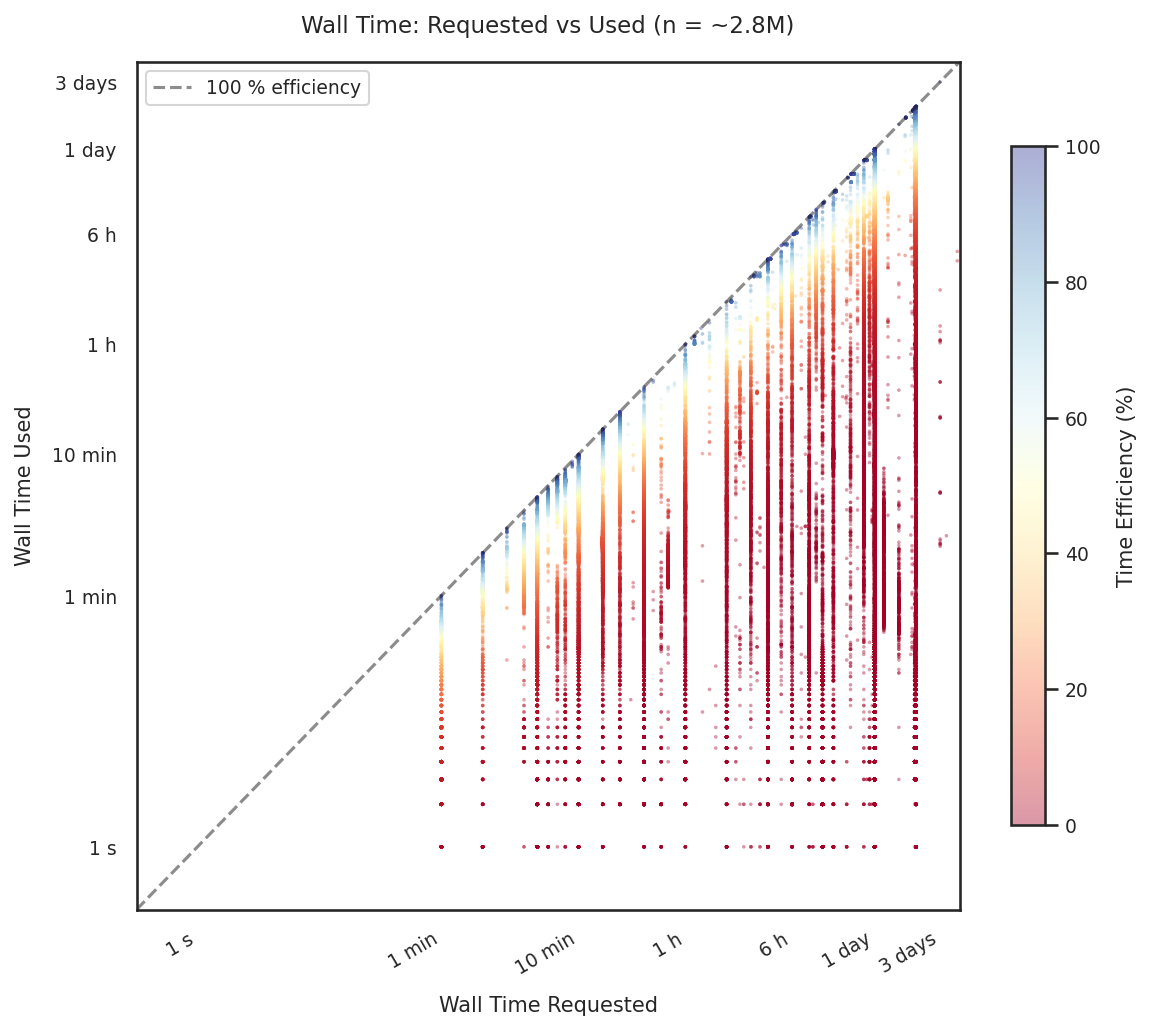


*Based on **~2.8M** jobs with time efficiency ≤ 100 %.
**~8.9k** jobs are excluded because their time limit was
not explicitly chosen by the user — either Slurm's INFINITE sentinel
(no limit) or a partition-level maximum of 365 days.*

*The [cluster defaults](https://docs.er.kcl.ac.uk/CREATE/running_jobs/)
(applied when no value is specified) are **1 CPU core**, **1 GB memory**,
and **24 h wall time**. The documented maximum wall time is **48 h** for
batch jobs and **4 h** for interactive jobs. Time limits are enforced:
jobs that exceed their limit are killed (TIMEOUT state).*

*Points below the diagonal finished before their time limit expired.
Over-requesting time does not waste compute (resources are released when
the job finishes), but it **increases queue wait time** — the scheduler
must find a slot where nodes are free for the full requested duration.*

**Notes on time limits >48 h.** ~9.6k jobs (0.3 %)
ran longer than 48 h, with time limits up to ~21 days. In Slurm there is
no distinction between requested and allocated time — `timelimit` is the
effective limit the job ran under. If a user requests more than the
partition allows, Slurm either rejects the job or caps the limit. A
time limit of 72 h or 168 h in the database therefore means it was
genuinely in effect. The data tells us that some jobs ran under limits
well above 48 h, but we do not know which partitions or configuration
made this possible.


In [24]:
time_sc = df[['timelimit_sec', 'elapsed_sec', 'time_eff']].dropna()
time_sc = time_sc[time_sc['time_eff'] <= 100]
# Filter non-user-chosen time limits:
# - Slurm INFINITE (0xFFFFFFFE minutes ≈ 8170 years): 'no limit' sentinel
# - 365 days: partition-level MaxTime, not a user request
# Real user requests go up to ~21 days on some partitions.
n_no_limit = (time_sc['timelimit_sec'] >= 365 * 24 * 3600).sum()
time_sc = time_sc[time_sc['timelimit_sec'] < 365 * 24 * 3600]
time_sc['req_hrs'] = time_sc['timelimit_sec'] / 3600
time_sc['used_hrs'] = time_sc['elapsed_sec'] / 3600
time_sc['eff'] = time_sc['time_eff']

# Filter out zeros/near-zeros for log scale
time_sc = time_sc[(time_sc['req_hrs'] > 1e-4) & (time_sc['used_hrs'] > 1e-4)]

# Subsample for scatter plot
sample = time_sc.sample(min(80_000, len(time_sc)), random_state=42)

# Same range for both axes so the diagonal goes corner-to-corner
all_vals = pd.concat([time_sc['req_hrs'], time_sc['used_hrs']])
lo = 10 ** np.floor(np.log10(all_vals.quantile(0.001)))
hi = 10 ** np.ceil(np.log10(all_vals.quantile(0.999)))

# Human-readable ticks covering both requested and used ranges
_time_ticks = [
    (1/3600, '1 s'), (1/60, '1 min'), (10/60, '10 min'),
    (1, '1 h'), (6, '6 h'), (24, '1 day'), (72, '3 days'),
]
visible = [(v, l) for v, l in _time_ticks if lo <= v <= hi]

fig, ax = plt.subplots(figsize=(8, 7))
sc = ax.scatter(sample['req_hrs'], sample['used_hrs'],
                c=sample['eff'], cmap='RdYlBu', vmin=0, vmax=100,
                s=3, alpha=0.4, edgecolors='none', rasterized=True)
cbar = fig.colorbar(sc, ax=ax, shrink=0.8)
cbar.set_label('Time Efficiency (%)', fontsize=10)
cbar.ax.tick_params(labelsize=9)

ax.plot([lo, hi], [lo, hi], 'k--', lw=1.5, alpha=0.5, label='100 % efficiency')

ax.set_xlabel('Wall Time Requested', fontsize=10)
ax.set_ylabel('Wall Time Used', fontsize=10)
ax.set_title(f'Wall Time: Requested vs Used (n = {approx(len(time_sc))})', fontsize=11)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.tick_params(labelsize=9)

if visible:
    tick_vals, tick_labels = zip(*visible)
    ax.set_xticks(tick_vals)
    ax.set_xticklabels(tick_labels, fontsize=9, rotation=30, ha='right')
    ax.set_yticks(tick_vals)
    ax.set_yticklabels(tick_labels, fontsize=9)
ax.xaxis.set_minor_locator(mticker.NullLocator())
ax.yaxis.set_minor_locator(mticker.NullLocator())

ax.legend(fontsize=9)
plt.tight_layout()
savefig('time_requested_vs_used.png')
plt.show()

n_above_48h = (df['elapsed_sec'].dropna() > 48 * 3600).sum()

display(Markdown(f'''
*Based on **{approx(len(time_sc))}** jobs with time efficiency ≤ 100 %.
**{approx(n_no_limit)}** jobs are excluded because their time limit was
not explicitly chosen by the user — either Slurm's INFINITE sentinel
(no limit) or a partition-level maximum of 365 days.*

*The [cluster defaults](https://docs.er.kcl.ac.uk/CREATE/running_jobs/)
(applied when no value is specified) are **1 CPU core**, **1 GB memory**,
and **24 h wall time**. The documented maximum wall time is **48 h** for
batch jobs and **4 h** for interactive jobs. Time limits are enforced:
jobs that exceed their limit are killed (TIMEOUT state).*

*Points below the diagonal finished before their time limit expired.
Over-requesting time does not waste compute (resources are released when
the job finishes), but it **increases queue wait time** — the scheduler
must find a slot where nodes are free for the full requested duration.*

**Notes on time limits >48 h.** {approx(n_above_48h)} jobs ({n_above_48h/len(df)*100:.1f} %)
ran longer than 48 h, with time limits up to ~21 days. In Slurm there is
no distinction between requested and allocated time — `timelimit` is the
effective limit the job ran under. If a user requests more than the
partition allows, Slurm either rejects the job or caps the limit. A
time limit of 72 h or 168 h in the database therefore means it was
genuinely in effect. The data tells us that some jobs ran under limits
well above 48 h, but we do not know which partitions or configuration
made this possible.
'''))

  Saved cpu_vs_mem_efficiency.png


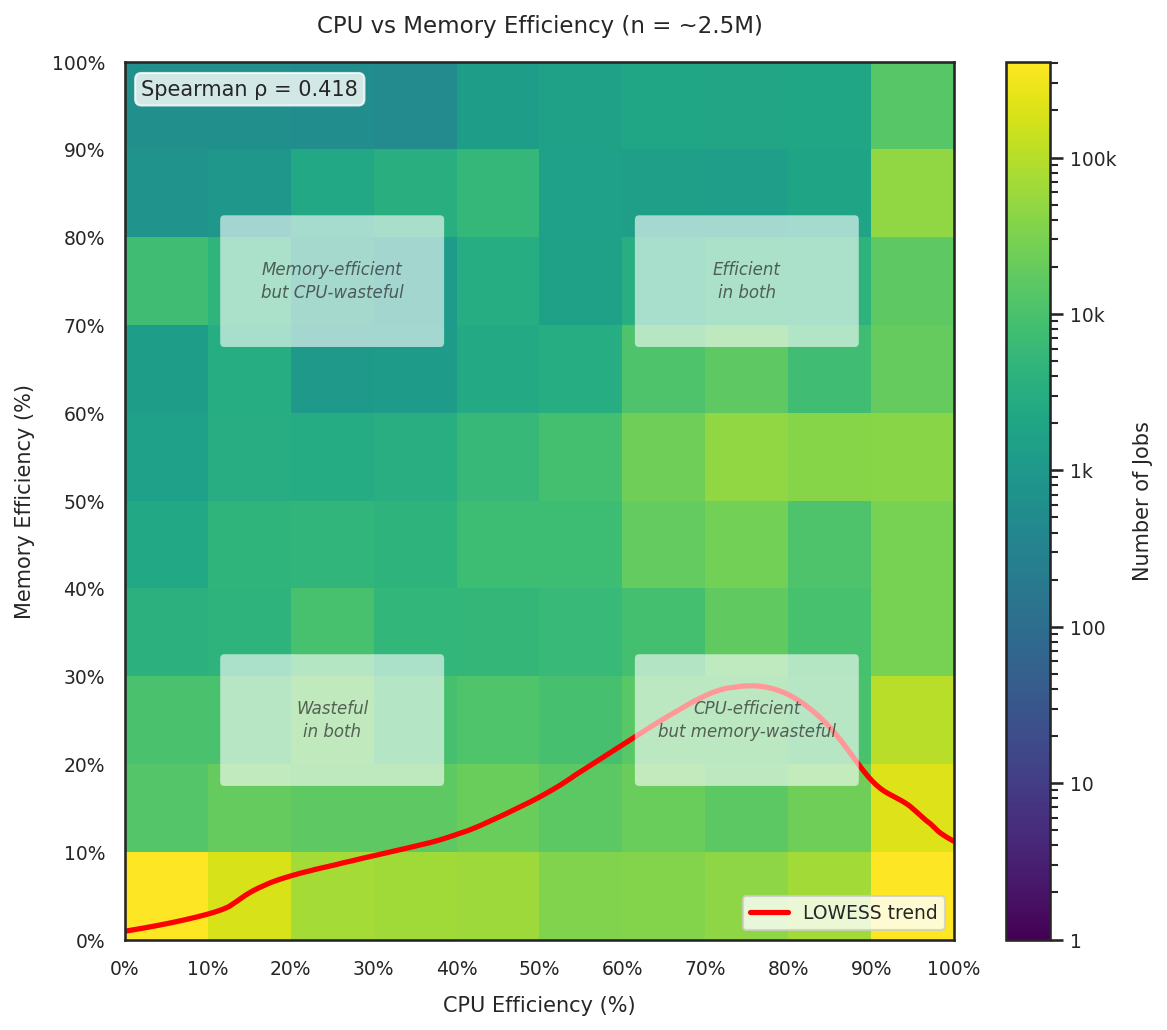

In [25]:
try:
    from statsmodels.nonparametric.smoothers_lowess import lowess as sm_lowess
    HAS_LOWESS = True
except ImportError:
    HAS_LOWESS = False
    print("statsmodels not installed — LOWESS trend line will be skipped.")

from matplotlib.patches import FancyBboxPatch

both = df[['cpu_eff_req', 'mem_eff']].dropna()
both = both[(both['cpu_eff_req'] <= 100) & (both['mem_eff'] <= 100)]

# 2D histogram with 10% bins
bins_10 = np.arange(0, 110, 10)
H, xedges, yedges = np.histogram2d(
    both['cpu_eff_req'], both['mem_eff'], bins=[bins_10, bins_10])

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.pcolormesh(xedges, yedges, H.T,
                   cmap='viridis',
                   norm=mcolors.LogNorm(vmin=1, vmax=H.max()))
# Colorbar with readable ticks
cbar = fig.colorbar(im, ax=ax, label='Number of Jobs')
cbar.set_label('Number of Jobs', fontsize=10)
cbar.ax.tick_params(labelsize=9)
cbar_ticks = [1, 10, 100, 1_000, 10_000, 100_000, 1_000_000]
cbar_ticks = [t for t in cbar_ticks if t <= H.max()]
cbar.set_ticks(cbar_ticks)
cbar.set_ticklabels(['1', '10', '100', '1k', '10k', '100k', '1M'][:len(cbar_ticks)])

# LOWESS trend line (subsample for speed)
if HAS_LOWESS:
    sample = both.sample(min(100_000, len(both)), random_state=42)
    smoothed = sm_lowess(sample['mem_eff'], sample['cpu_eff_req'], frac=0.3)
    ax.plot(smoothed[:, 0], smoothed[:, 1], color='red', linewidth=2.5,
            label='LOWESS trend')

ax.set_xlabel('CPU Efficiency (%)', fontsize=10)
ax.set_ylabel('Memory Efficiency (%)', fontsize=10)
ax.set_title(f'CPU vs Memory Efficiency (n = {approx(len(both))})', fontsize=11)
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.set_xticks(np.arange(0, 110, 10))
ax.set_yticks(np.arange(0, 110, 10))
ax.set_xticklabels([f'{x}%' for x in range(0, 110, 10)], fontsize=9)
ax.set_yticklabels([f'{y}%' for y in range(0, 110, 10)], fontsize=9)

# Quadrant labels — uniform boxes via manually placed patches
box_w, box_h = 26, 14  # data coords (% of 0–100 range)
quad_labels = [
    (25, 75, 'Memory-efficient\nbut CPU-wasteful'),
    (75, 75, 'Efficient\nin both'),
    (25, 25, 'Wasteful\nin both'),
    (75, 25, 'CPU-efficient\nbut memory-wasteful'),
]
for cx, cy, txt in quad_labels:
    patch = FancyBboxPatch(
        (cx - box_w / 2, cy - box_h / 2), box_w, box_h,
        boxstyle='round,pad=0.5', facecolor='white', alpha=0.6,
        edgecolor='none', zorder=3)
    ax.add_patch(patch)
    ax.text(cx, cy, txt, fontsize=8, alpha=0.7, fontstyle='italic',
            ha='center', va='center', linespacing=1.4, zorder=4)

# Spearman correlation
rho, pval = sp_stats.spearmanr(both['cpu_eff_req'], both['mem_eff'])
ax.text(0.02, 0.98, f'Spearman ρ = {rho:.3f}',
        transform=ax.transAxes, fontsize=10, va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

if HAS_LOWESS:
    ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
savefig('cpu_vs_mem_efficiency.png')
plt.show()


---
# 2. Faculty Efficiency Stats

  Saved faculty_job_outcomes.png


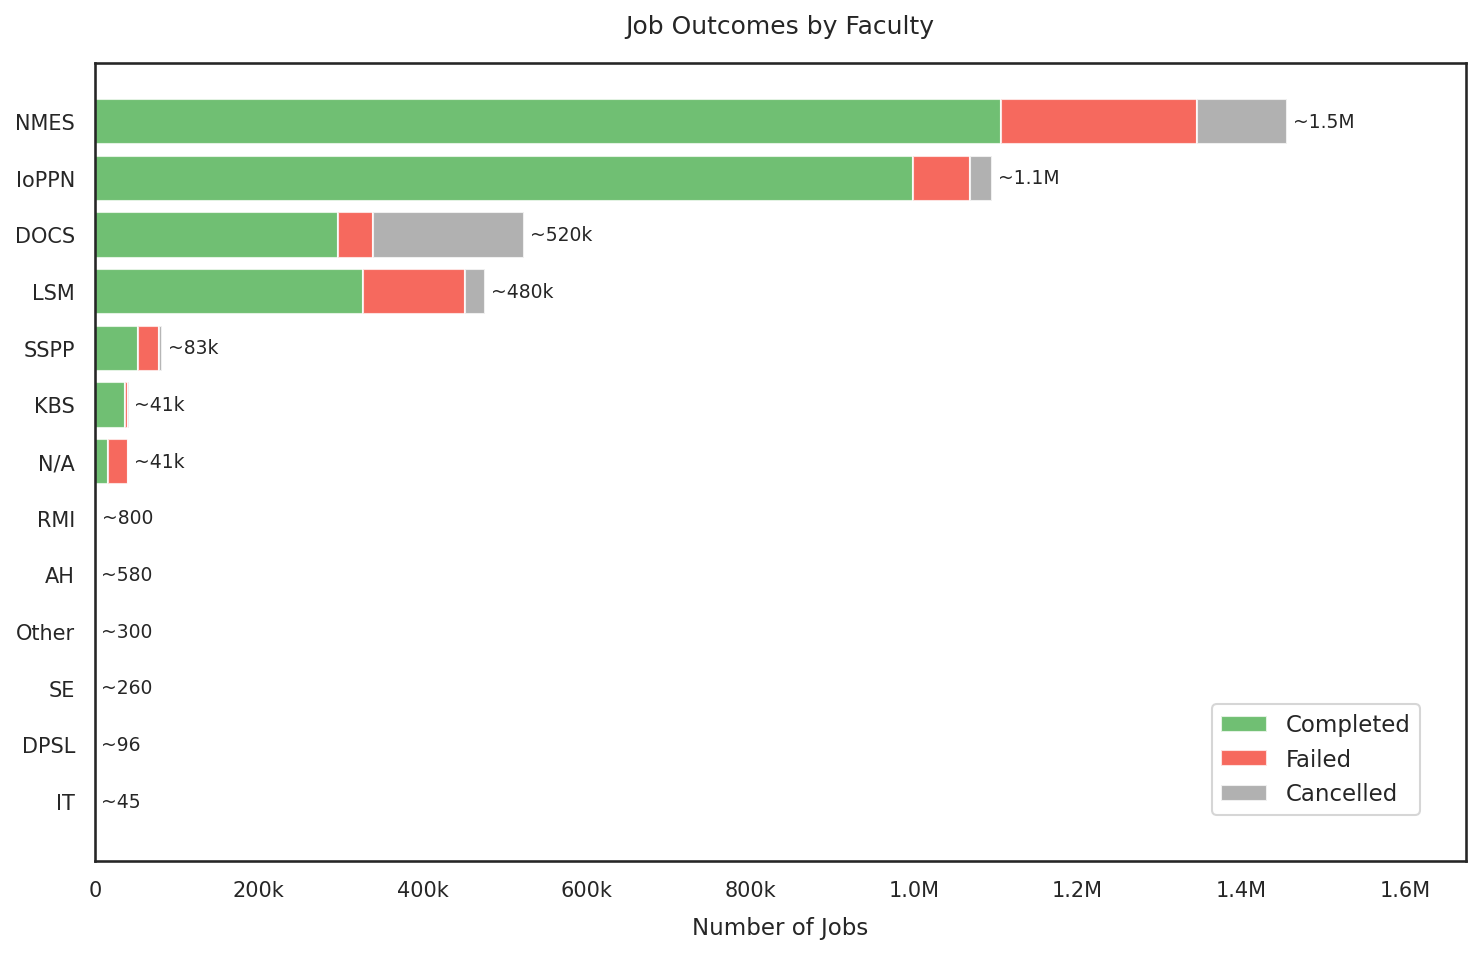


*Numbers at the tip of each bar show the approximate total number of jobs submitted.*

**State definitions:**
- **Completed**: jobs that finished successfully (Slurm state COMPLETED).
- **Failed**: jobs that terminated abnormally — includes FAILED, TIMEOUT,
  NODE_FAIL, PREEMPTED, and OUT_OF_MEMORY.
- **Cancelled**: jobs cancelled by the user or an administrator before
  completion (excluded from failure counts as these are intentional).


In [26]:
df_out = df_agg.sort_values('job_count', ascending=True).copy()

fig, ax = plt.subplots(figsize=(10, max(6, len(df_out) * 0.5)))

y = range(len(df_out))
ax.barh(y, df_out['job_count_success'].values, color=C_OK,
        label='Completed', alpha=0.8)
ax.barh(y, df_out['job_count_failed'].values,
        left=df_out['job_count_success'].values,
        color=C_FAIL, label='Failed', alpha=0.8)
ax.barh(y, df_out['cancelled'].values,
        left=(df_out['job_count_success'] + df_out['job_count_failed']).values,
        color=C_CAN, label='Cancelled', alpha=0.8)

ax.set_yticks(list(y))
ax.set_yticklabels(df_out['faculty_short'].values)
ax.set_xlabel('Number of Jobs')
ax.xaxis.set_major_formatter(COUNT_FMT)
ax.set_title('Job Outcomes by Faculty')
ax.legend(loc='lower right', borderaxespad=2)

# Annotate totals at tip
max_count = df_out['job_count'].max()
for i, (_, row) in enumerate(df_out.iterrows()):
    ax.text(row['job_count'] + max_count * 0.005, i,
            approx(row['job_count']), va='center', fontsize=9)

ax.set_xlim(0, max_count * 1.15)

plt.tight_layout()
savefig('faculty_job_outcomes.png')
plt.show()

display(Markdown('''
*Numbers at the tip of each bar show the approximate total number of jobs submitted.*

**State definitions:**
- **Completed**: jobs that finished successfully (Slurm state COMPLETED).
- **Failed**: jobs that terminated abnormally — includes FAILED, TIMEOUT,
  NODE_FAIL, PREEMPTED, and OUT_OF_MEMORY.
- **Cancelled**: jobs cancelled by the user or an administrator before
  completion (excluded from failure counts as these are intentional).
'''))

| Rank | Faculty | CPU mean (95% CI) | n (CPU) | Memory mean (95% CI) | n (Mem) | Time mean (95% CI) | n (Time) |
|-----:|:--------|:------------------|--------:|:---------------------|--------:|:-------------------|--------:|
| 1 | **SSPP** | 82.9% (82.7–83.1%) | 54,160 | 16.5% (16.4–16.6%) | 53,637 | 12.9% (12.7–13.1%) | 53,070 |
| 2 | **NMES** | 77.6% (77.5–77.7%) | 1,131,383 | 19.4% (19.3–19.4%) | 1,036,958 | 19.6% (19.5–19.7%) | 1,110,513 |
| 3 | **Other** | 76.4% (71.5–81.4%) | 142 | 14.5% (10.5–18.4%) | 134 | 1.4% (0.1–2.8%) | 152 |
| 4 | **DOCS** | 55.1% (54.9–55.2%) | 276,973 | 16.3% (16.2–16.4%) | 246,478 | 8.1% (8.0–8.1%) | 296,857 |
| 5 | **LSM** | 53.3% (53.2–53.4%) | 320,438 | 13.5% (13.4–13.5%) | 310,025 | 6.6% (6.6–6.7%) | 328,608 |
| 6 | **IoPPN** | 44.4% (44.3–44.4%) | 971,112 | 23.0% (23.0–23.1%) | 941,941 | 6.5% (6.5–6.6%) | 999,160 |
| 7 | **AH** | 32.0% (27.3–36.7%) | 240 | 12.9% (8.6–17.2%) | 113 | 16.7% (13.9–19.4%) | 228 |
| 8 | **N/A** | 30.7% (30.3–31.1%) | 15,542 | 8.2% (7.9–8.4%) | 15,246 | 2.1% (2.0–2.2%) | 16,587 |
| 9 | **RMI** | 22.8% (19.8–25.8%) | 431 | 15.0% (13.3–16.8%) | 370 | 10.1% (8.3–11.9%) | 367 |
| 10 | **SE** | 3.2% (2.7–3.8%) | 180 | 3.0% (1.1–5.0%) | 180 | 5.7% (4.0–7.5%) | 173 |
| 11 | **KBS** | 0.6% (0.6–0.6%) | 36,826 | 0.2% (0.2–0.3%) | 36,719 | 0.2% (0.2–0.2%) | 36,694 |

/tmp/ipykernel_1766848/1969951449.py:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


  Saved faculty_efficiency_barplots.png


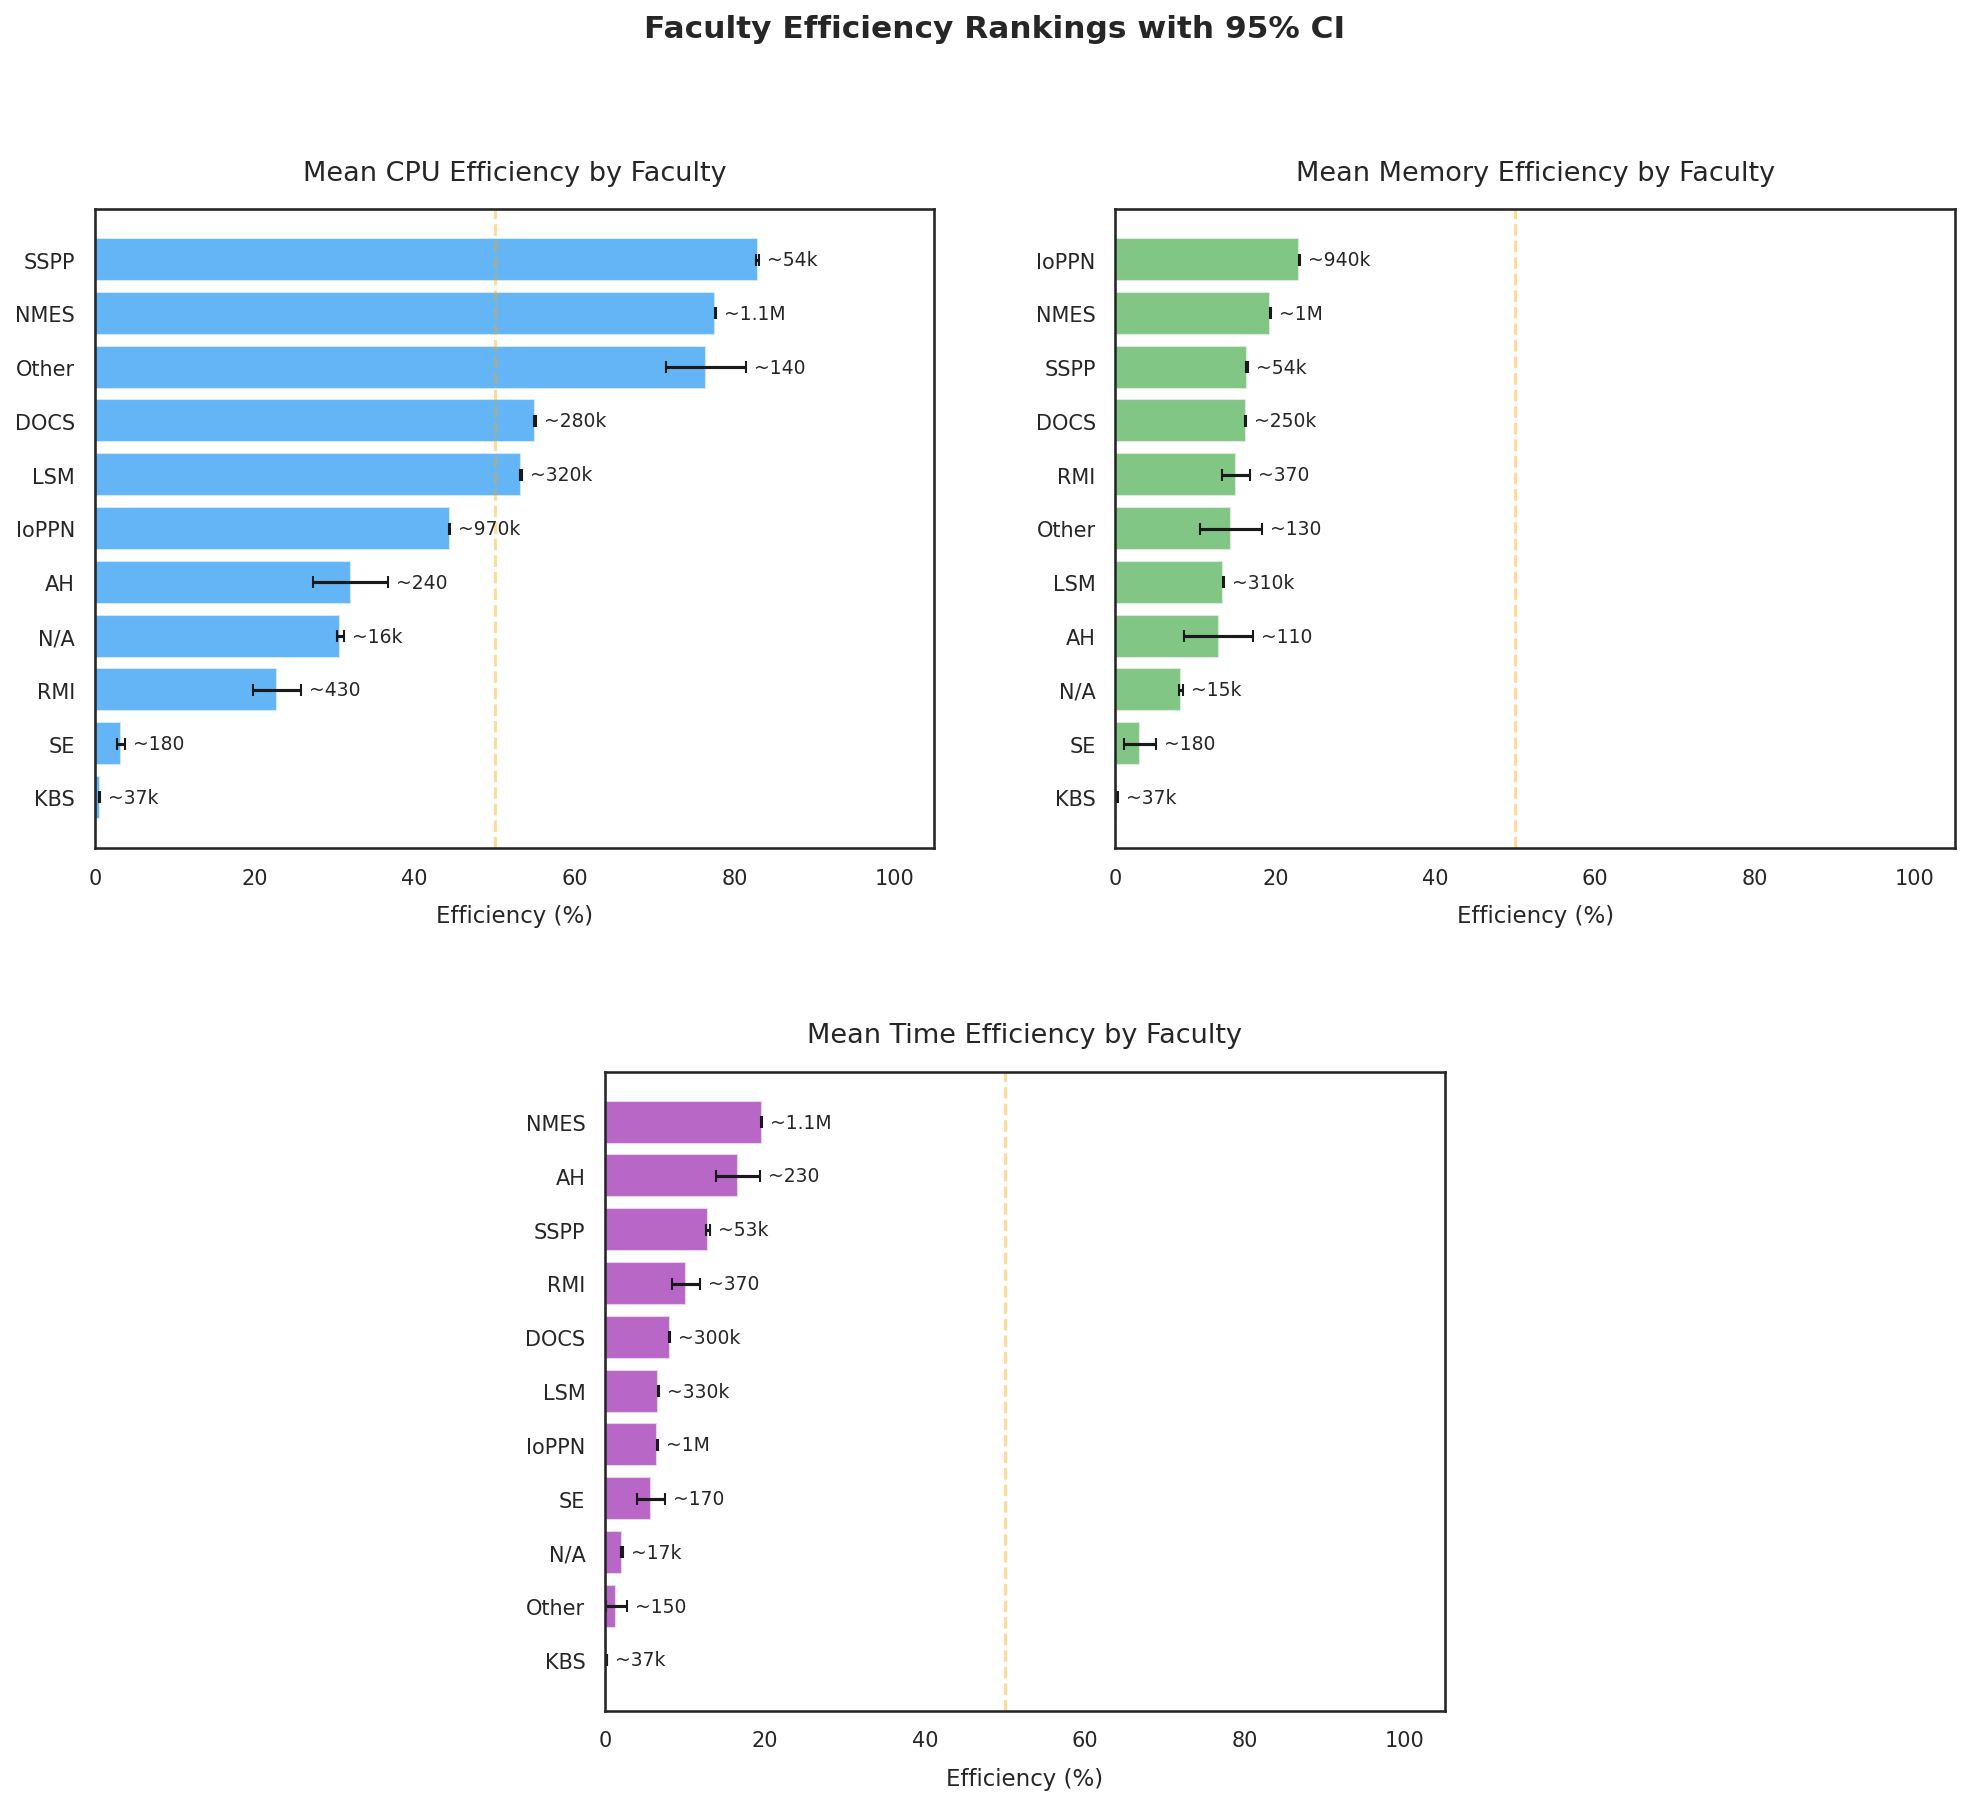

In [27]:
def faculty_ci_stats(col):
    """Compute per-faculty mean and 95% CI from job-level data (eff <= 100%)."""
    rows = []
    for fac in df['faculty'].unique():
        vals = df.loc[df['faculty'] == fac, col].dropna()
        vals = vals[vals <= 100]
        if len(vals) < 50:
            continue
        mean = vals.mean()
        se   = vals.std() / np.sqrt(len(vals))
        ci   = 1.96 * se
        rows.append({
            'faculty': fac,
            'faculty_short': SHORT.get(fac, fac),
            'mean': mean,
            'ci': ci,
            'n': len(vals),
        })
    return pd.DataFrame(rows).sort_values('mean', ascending=True)

cpu_fstats  = faculty_ci_stats('cpu_eff_req')
mem_fstats  = faculty_ci_stats('mem_eff')
time_fstats = faculty_ci_stats('time_eff')

# --- Markdown table (kept for reference) ---
tbl = cpu_fstats.sort_values('mean', ascending=False)[['faculty_short']].copy()
tbl = tbl.rename(columns={'faculty_short': 'Faculty'})

for label, fstats in [('CPU', cpu_fstats), ('Mem', mem_fstats), ('Time', time_fstats)]:
    lookup = fstats.set_index('faculty_short')
    tbl[f'{label} mean (95% CI)'] = tbl['Faculty'].map(
        lambda f, lk=lookup: f"{lk.loc[f, 'mean']:.1f}% ({lk.loc[f, 'mean']-lk.loc[f, 'ci']:.1f}–{lk.loc[f, 'mean']+lk.loc[f, 'ci']:.1f}%)"
        if f in lk.index else '—')
    tbl[f'n ({label})'] = tbl['Faculty'].map(
        lambda f, lk=lookup: f"{lk.loc[f, 'n']:,}" if f in lk.index else '—')

header = '| Rank | Faculty | CPU mean (95% CI) | n (CPU) | Memory mean (95% CI) | n (Mem) | Time mean (95% CI) | n (Time) |'
sep    = '|-----:|:--------|:------------------|--------:|:---------------------|--------:|:-------------------|--------:|'
rows = [header, sep]
for i, (_, row) in enumerate(tbl.iterrows(), 1):
    rows.append(
        f"| {i} | **{row['Faculty']}** "
        f"| {row['CPU mean (95% CI)']} | {row['n (CPU)']} "
        f"| {row['Mem mean (95% CI)']} | {row['n (Mem)']} "
        f"| {row['Time mean (95% CI)']} | {row['n (Time)']} |"
    )
display(Markdown('\n'.join(rows)))

# --- Bar plots: CPU + Memory top row, Time centred bottom row ---
n_facs = len(cpu_fstats)
row_h = max(6, n_facs * 0.45)
fig = plt.figure(figsize=(16, row_h * 2 + 1))
gs = fig.add_gridspec(2, 4, hspace=0.35, wspace=0.55)
ax_cpu  = fig.add_subplot(gs[0, 0:2])
ax_mem  = fig.add_subplot(gs[0, 2:4])
ax_time = fig.add_subplot(gs[1, 1:3])

configs = [
    (ax_cpu,  cpu_fstats,  C_CPU,  'Mean CPU Efficiency by Faculty'),
    (ax_mem,  mem_fstats,  C_MEM,  'Mean Memory Efficiency by Faculty'),
    (ax_time, time_fstats, C_TIME, 'Mean Time Efficiency by Faculty'),
]

for ax, fstats, colour, title in configs:
    ax.barh(fstats['faculty_short'], fstats['mean'], xerr=fstats['ci'],
            color=colour, alpha=0.7, edgecolor='white', capsize=3)
    ax.set_xlim(0, 105)
    ax.axvline(50, color='orange', ls='--', alpha=0.4)
    ax.set_xlabel('Efficiency (%)', fontsize=11)
    ax.set_title(title, fontsize=13)
    for _, row in fstats.iterrows():
        x_pos = row['mean'] + row['ci'] + 1
        # If label would go outside plot, place it inside the bar
        if x_pos > 100:
            ax.text(row['mean'] - 2, row['faculty_short'],
                    approx(row['n']), va='center', ha='right', fontsize=9,
                    color='white', fontweight='bold')
        else:
            ax.text(x_pos, row['faculty_short'],
                    approx(row['n']), va='center', fontsize=9)

plt.suptitle('Faculty Efficiency Rankings with 95% CI',
             fontsize=15, fontweight='bold')
plt.tight_layout()
savefig('faculty_efficiency_barplots.png')
plt.show()

/tmp/ipykernel_1766848/1960221345.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


  Saved faculty_efficiency_violins.png


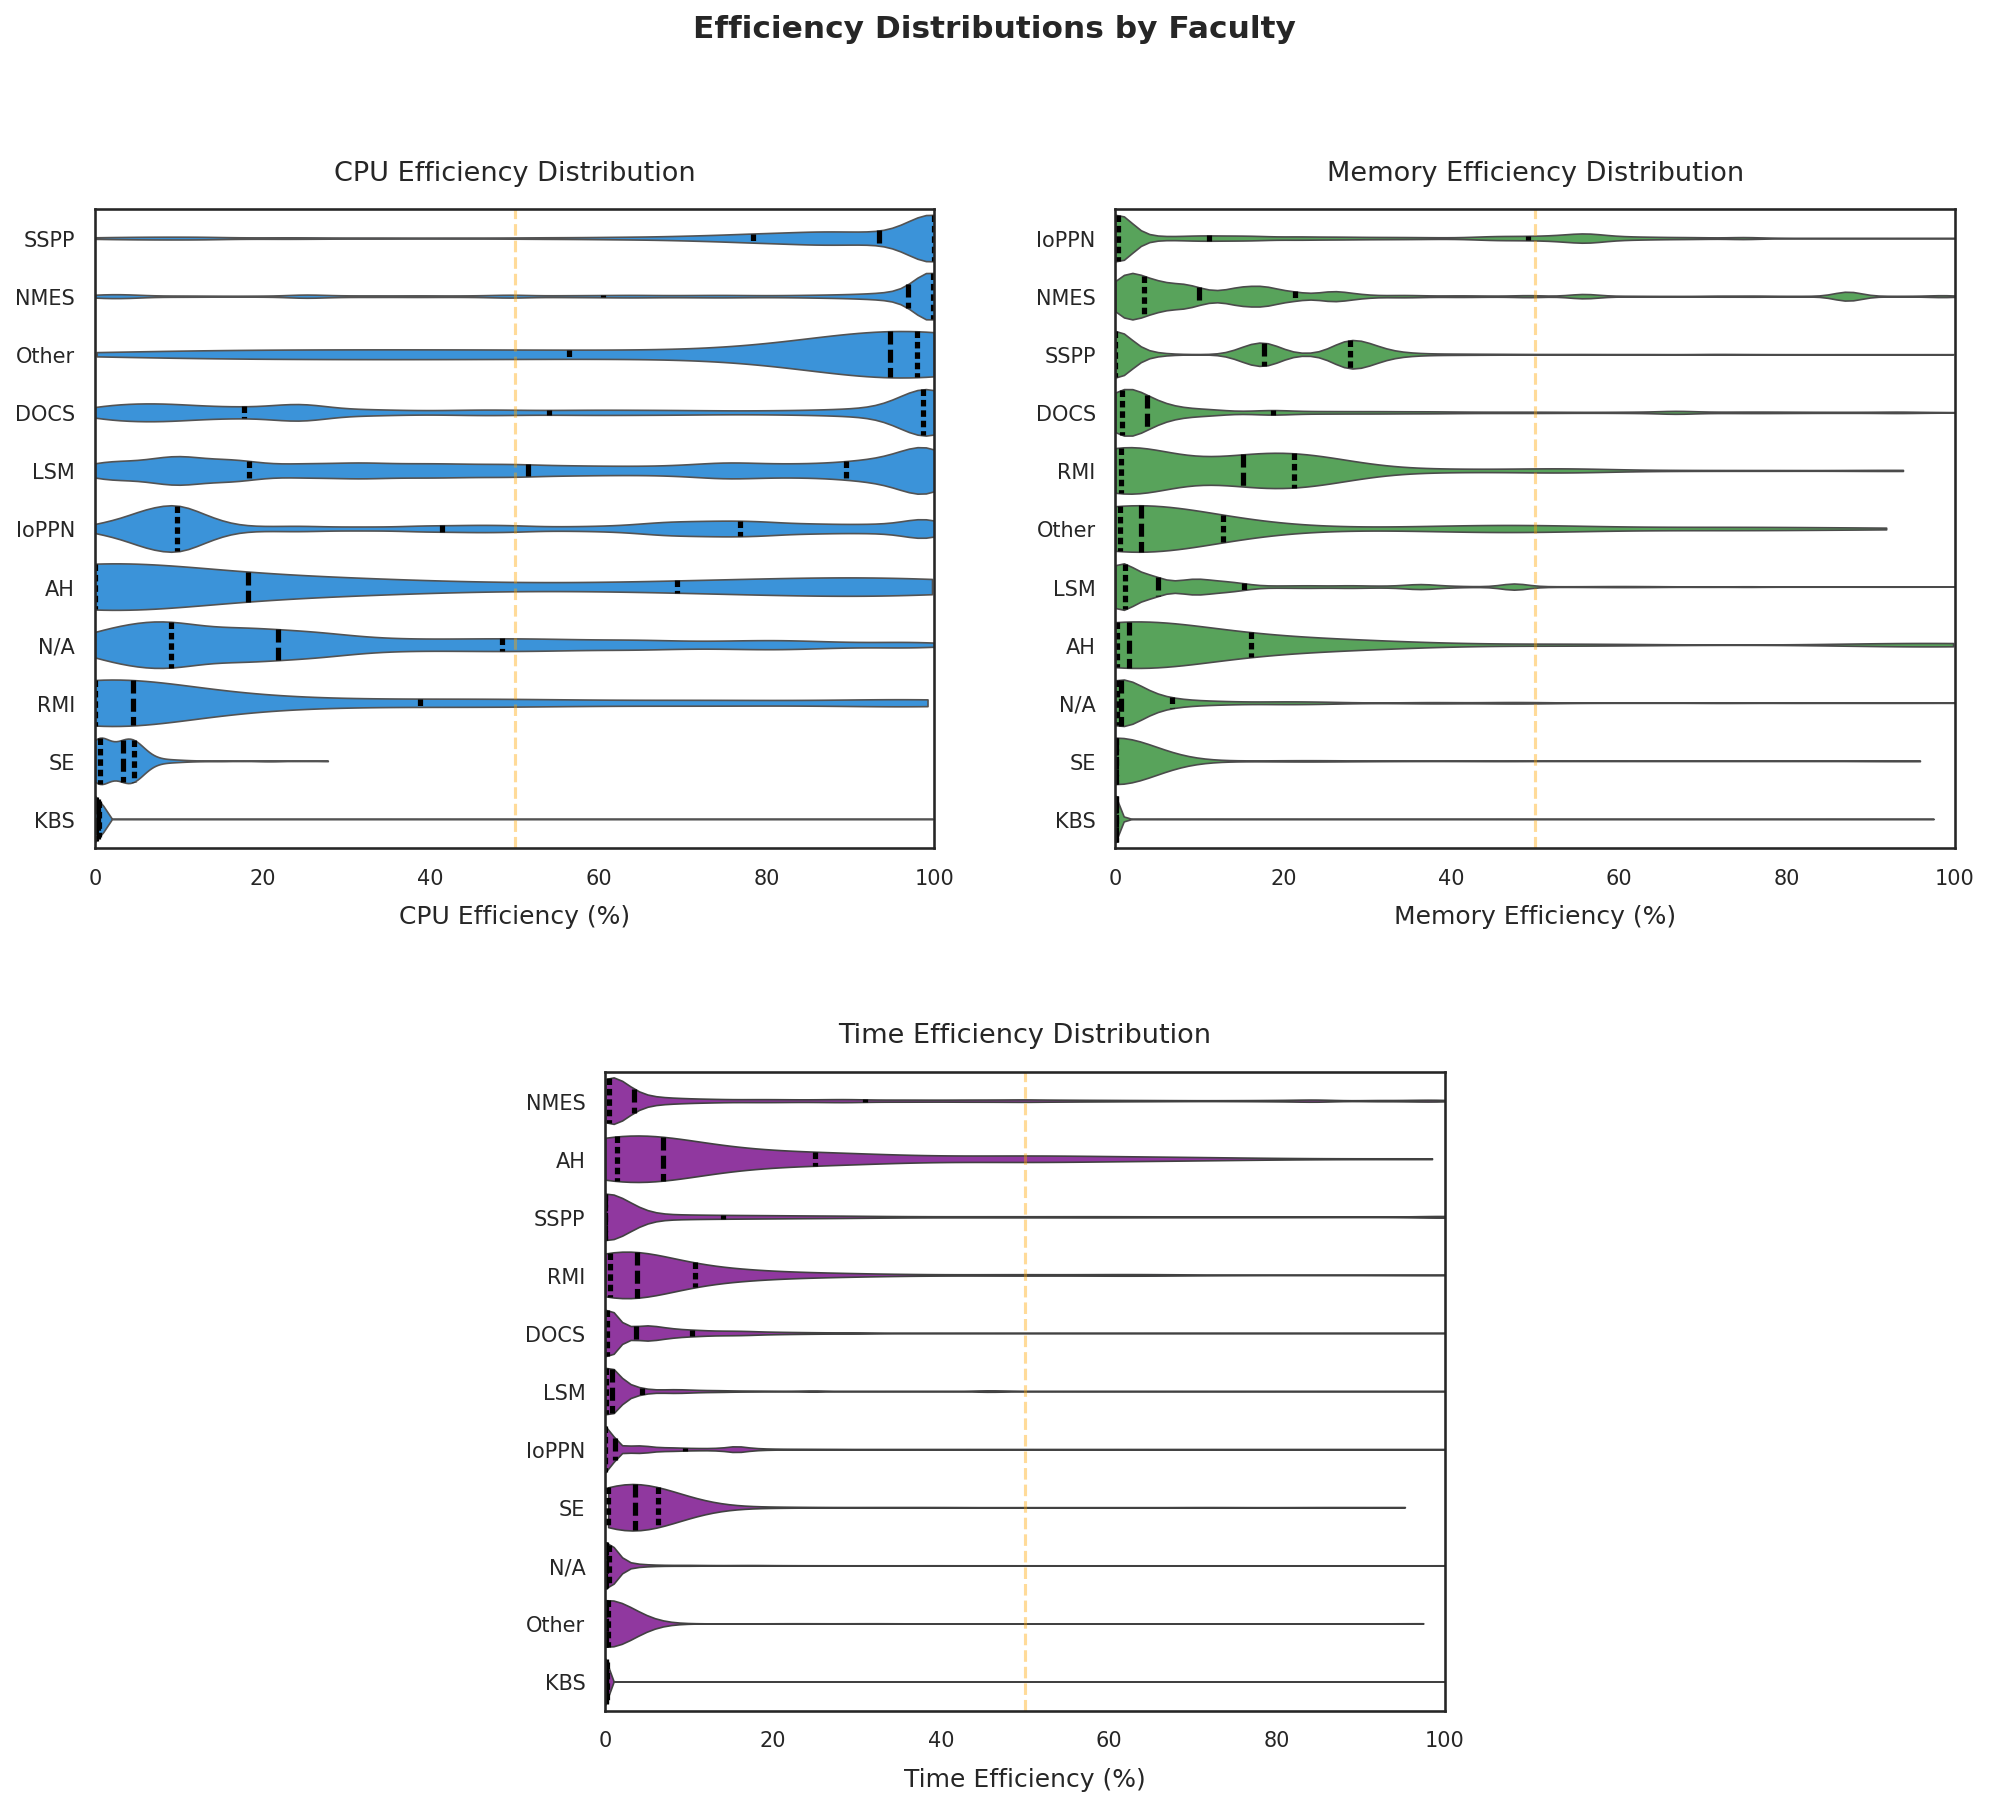


*Faculties with fewer than 50 jobs are excluded.
Internal lines show quartiles (25th, 50th, 75th percentile).
All violins are normalised to the same maximum width, so a wider section
shows where a larger share of that faculty's jobs falls.
Job counts per faculty are shown in the barplot above.*


In [28]:
# Only faculties with >= 50 jobs for meaningful violins
fac_counts = df['faculty'].value_counts()
big_facs = fac_counts[fac_counts >= 50].index.tolist()

# Order by mean efficiency (desc) for each metric
fac_cpu_means = (df[df['faculty'].isin(big_facs) & (df['cpu_eff_req'] <= 100)
                    & df['cpu_eff_req'].notna()]
                 .groupby('faculty')['cpu_eff_req'].mean()
                 .sort_values(ascending=False))
fac_order_cpu = [SHORT.get(f, f) for f in fac_cpu_means.index]

fac_mem_means = (df[df['faculty'].isin(big_facs) & (df['mem_eff'] <= 100)
                    & df['mem_eff'].notna()]
                 .groupby('faculty')['mem_eff'].mean()
                 .sort_values(ascending=False))
fac_order_mem = [SHORT.get(f, f) for f in fac_mem_means.index]

fac_time_means = (df[df['faculty'].isin(big_facs) & (df['time_eff'] <= 100)
                     & df['time_eff'].notna()]
                  .groupby('faculty')['time_eff'].mean()
                  .sort_values(ascending=False))
fac_order_time = [SHORT.get(f, f) for f in fac_time_means.index]

n_facs = len(big_facs)
row_h = max(6, n_facs * 0.5)
fig = plt.figure(figsize=(16, row_h * 2 + 1))
gs = fig.add_gridspec(2, 4, hspace=0.35, wspace=0.55)
ax_cpu  = fig.add_subplot(gs[0, 0:2])
ax_mem  = fig.add_subplot(gs[0, 2:4])
ax_time = fig.add_subplot(gs[1, 1:3])

configs = [
    (ax_cpu,  'cpu_eff_req', fac_order_cpu,  C_CPU,  'CPU Efficiency (%)',    'CPU Efficiency Distribution'),
    (ax_mem,  'mem_eff',     fac_order_mem,  C_MEM,  'Memory Efficiency (%)', 'Memory Efficiency Distribution'),
    (ax_time, 'time_eff',    fac_order_time, C_TIME, 'Time Efficiency (%)',   'Time Efficiency Distribution'),
]

for ax, col, order, colour, xlabel, title in configs:
    vdata = df[df['faculty'].isin(big_facs)
               & df[col].notna()
               & (df[col] <= 100)].copy()
    sns.violinplot(data=vdata, y='faculty_short', x=col,
                   ax=ax, cut=0, order=order,
                   density_norm='width', inner='quartile', color=colour,
                   linewidth=0.8)
    # Make quartile lines black and thick (before adding other lines)
    for line in ax.lines:
        line.set_color('black')
        line.set_linewidth(2.5)
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel('', fontsize=12)
    ax.set_title(title, fontsize=13)
    ax.axvline(50, color='orange', ls='--', alpha=0.4)
    ax.set_xlim(0, 100)

plt.suptitle('Efficiency Distributions by Faculty',
             fontsize=15, fontweight='bold')
plt.tight_layout()
savefig('faculty_efficiency_violins.png')
plt.show()

display(Markdown('''
*Faculties with fewer than 50 jobs are excluded.
Internal lines show quartiles (25th, 50th, 75th percentile).
All violins are normalised to the same maximum width, so a wider section
shows where a larger share of that faculty's jobs falls.
Job counts per faculty are shown in the barplot above.*
'''))

In [29]:
# Merge small non-faculty categories into a single "Other" group
MERGE_TO_OTHER = {'RMI', 'SE', 'Other'}

df['faculty_short_merged'] = df['faculty_short'].apply(
    lambda x: 'Other' if x in MERGE_TO_OTHER else x)

# Also create a merged version of the SHORT lookup for use in plots
SHORT_MERGED = {}
for full_name, abbrev in SHORT.items():
    SHORT_MERGED[full_name] = 'Other' if abbrev in MERGE_TO_OTHER else abbrev

print('Faculty categories after merging:')
print(df['faculty_short_merged'].value_counts().to_string())

Faculty categories after merging:
faculty_short_merged
NMES     1158224
IoPPN    1008301
LSM       339435
DOCS      299032
SSPP       56472
KBS        36827
N/A        16886
Other        774
AH           262
IT            25
DPSL          17


/tmp/ipykernel_1766848/1651570868.py:71: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


  Saved faculty_efficiency_boxplots.png


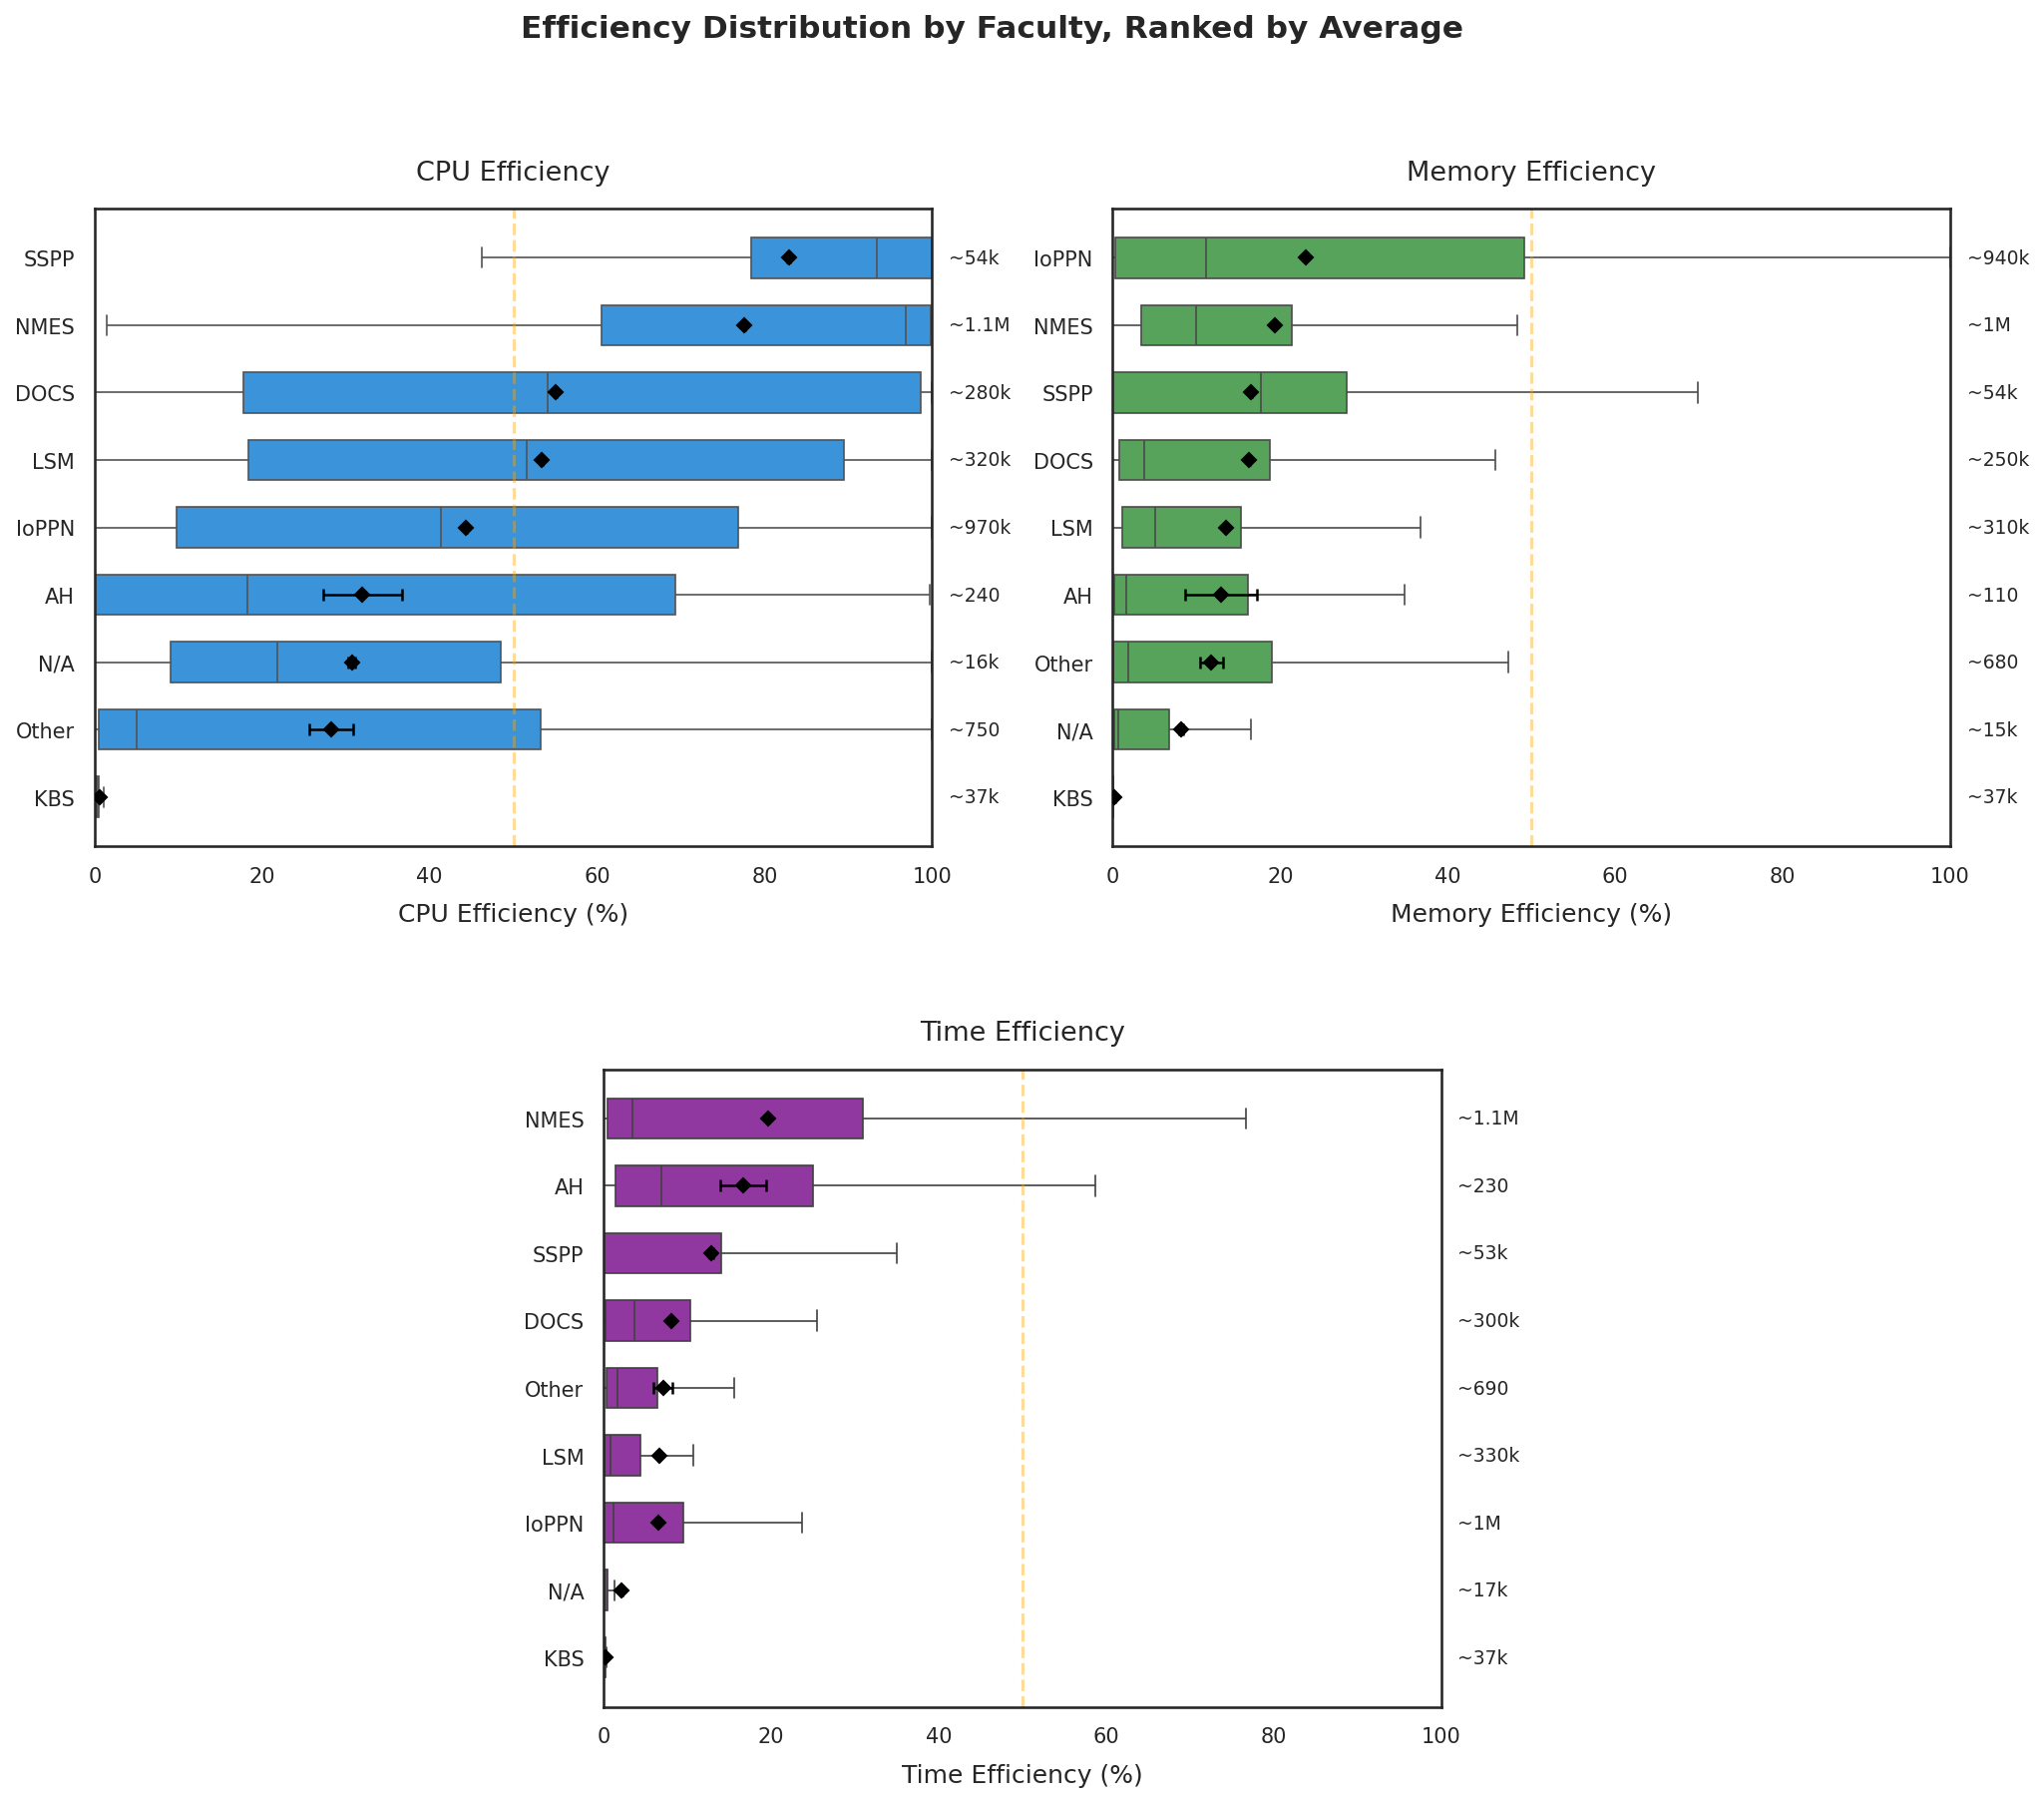


*Boxplots show median (line), IQR (box), and whiskers extending to 1.5× IQR.
Black diamonds show the mean with 95% CI error bars.
Faculties with fewer than 50 jobs are excluded.
Other merges RMI, SE, IT, N/A, and Other categories.
Ranked from highest (top) to lowest (bottom) average efficiency.
Job counts shown to the right of each row.*


In [30]:
# Faculty efficiency boxplots with mean + 95% CI overlay
# Uses merged faculty categories (Other combines RMI, SE, IT, N/A, Other)
from scipy.stats import sem

MIN_JOBS = 50

def merged_faculty_stats(col):
    """Compute per-merged-faculty stats for ordering and annotations."""
    rows = []
    for fac in df['faculty_short_merged'].unique():
        vals = df.loc[df['faculty_short_merged'] == fac, col].dropna()
        vals = vals[vals <= 100]
        if len(vals) < MIN_JOBS:
            continue
        mean = vals.mean()
        ci = 1.96 * sem(vals)
        rows.append({'faculty': fac, 'mean': mean, 'ci': ci, 'n': len(vals)})
    return pd.DataFrame(rows).sort_values('mean', ascending=False)

cpu_mstats  = merged_faculty_stats('cpu_eff_req')
mem_mstats  = merged_faculty_stats('mem_eff')
time_mstats = merged_faculty_stats('time_eff')

n_facs = len(cpu_mstats)
row_h = max(6, n_facs * 0.55)
fig = plt.figure(figsize=(16, row_h * 2 + 1))
gs = fig.add_gridspec(2, 4, hspace=0.35, wspace=0.55)
ax_cpu  = fig.add_subplot(gs[0, 0:2])
ax_mem  = fig.add_subplot(gs[0, 2:4])
ax_time = fig.add_subplot(gs[1, 1:3])

configs = [
    (ax_cpu,  'cpu_eff_req', cpu_mstats,  C_CPU,  'CPU Efficiency (%)',    'CPU Efficiency'),
    (ax_mem,  'mem_eff',     mem_mstats,  C_MEM,  'Memory Efficiency (%)', 'Memory Efficiency'),
    (ax_time, 'time_eff',    time_mstats, C_TIME, 'Time Efficiency (%)',   'Time Efficiency'),
]

for ax, col, mstats, colour, xlabel, title in configs:
    order = mstats['faculty'].tolist()
    bdata = df[df['faculty_short_merged'].isin(order)
               & df[col].notna()
               & (df[col] <= 100)].copy()

    sns.boxplot(data=bdata, y='faculty_short_merged', x=col,
                ax=ax, order=order, color=colour, width=0.6,
                linewidth=0.8, showfliers=False)

    # Overlay mean as diamond with 95% CI error bars
    for _, row in mstats.iterrows():
        y_pos = order.index(row['faculty'])
        ax.errorbar(row['mean'], y_pos,
                    xerr=row['ci'], fmt='D', color='black',
                    markersize=5, capsize=3, capthick=1.2,
                    elinewidth=1.2, zorder=5)

    # Annotate job counts outside the plot area
    for _, row in mstats.iterrows():
        y_pos = order.index(row['faculty'])
        ax.text(1.02, y_pos, approx(row['n']),
                va='center', fontsize=9,
                transform=ax.get_yaxis_transform())

    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel('', fontsize=12)
    ax.set_title(title, fontsize=13)
    ax.axvline(50, color='orange', ls='--', alpha=0.4)
    ax.set_xlim(0, 100)

plt.suptitle('Efficiency Distribution by Faculty, Ranked by Average',
             fontsize=15, fontweight='bold')
plt.tight_layout()
savefig('faculty_efficiency_boxplots.png')
plt.show()

display(Markdown(f"""
*Boxplots show median (line), IQR (box), and whiskers extending to 1.5\u00d7 IQR.
Black diamonds show the mean with 95% CI error bars.
Faculties with fewer than {MIN_JOBS} jobs are excluded.
Other merges RMI, SE, IT, N/A, and Other categories.
Ranked from highest (top) to lowest (bottom) average efficiency.
Job counts shown to the right of each row.*
"""))